# Speech Emotion Recognition - WavLM v4 - EDA, Focal Loss & Trusted Noise Filtering

> [IMPORTANT] Output yang tersimpan masih berasal dari run v3 sebelumnya. Source code notebook ini sudah disiapkan untuk v4, jadi jalankan ulang dari awal di Kaggle sebelum memakai angka metrik.

**Target emosi:** Netral · Senang · Sedih · Marah · Takut · Jijik

## Perubahan v3 ke v4

| # | Komponen | Perubahan v4 |
|---|---|---|
| 1 | **Input Checkpoint** | Checkpoint Stage 2 v3 dipakai sebagai inisialisasi eksplisit. Kandidat legacy v7 tidak lagi dipilih otomatis. |
| 2 | **Proteksi Re-run** | Fallback ke checkpoint output v4 lama dihapus agar rerun tidak diam-diam melanjutkan file yang tertinggal di session Kaggle. |
| 3 | **Namespace Output** | Checkpoint, log, evaluasi, heatmap, dan package hasil modeling menggunakan namespace v4. |
| 4 | **Lineage** | Urutan eksperimen dicatat sebagai checkpoint v3 Stage 2 -> v4 Stage 1 -> v4 Stage 2. |
| 5 | **Kaggle Compatibility** | Candidate path mencakup Kaggle Input dan path lokal `pipeline/ser_wavlm_v3_best.pt`. File lokal tetap harus diunggah atau dilampirkan ke Kaggle agar dapat ditemukan. |
| 6 | **Metrik Final** | Laporan test, train, validation, macro metrics, confusion matrix aktual, dan error pairs tetap dihitung dari checkpoint final v4. |
| 7 | **Audit Augmentasi** | Notebook tetap menampilkan jumlah data hasil augmentasi per sumber dan per kelas sehingga hasil v4 dapat diverifikasi. |
| 8 | **Baseline Stability** | Seed, augmentasi, Mixup, label smoothing, dropout, dan arsitektur v3 dipertahankan agar perubahan v4 terisolasi pada checkpoint lineage dan namespace output. |

Catatan: v4 adalah continuation fine-tuning dari checkpoint Stage 2 v3 pada dataset dan split yang sama. Ini bukan eksperimen independen dari WavLM base.

### Target eksperimen v4

Target berikut adalah sasaran evaluasi di Kaggle, bukan hasil yang sudah tercapai:

- Recall `sedih` minimal 80%.
- Recall `senang` minimal 80%.
- Precision `takut` minimal 80%.
- Precision `jijik` minimal 80%.
- CREMA-D, terutama kelas `sedih`, meningkat tanpa mengorbankan performa sumber lain.

### Catatan desain v4

CREMA-D tidak diberi augmentasi pada baseline karena masalah utamanya bukan kekurangan jumlah sampel, melainkan dominasi sumber data dan ambiguitas label. Jika augmentasi CREMA-D ingin diuji, lakukan sebagai ablation terpisah dengan subset dan seed yang terdokumentasi.

## Riwayat v1 ke v2

| # | Komponen | Perubahan v2 |
|---|---|---|
| ① | **EDA Pre-Augmentation** | 7-point EDA: Distribusi kelas, durasi outlier (0.35-4.0s), file corrupt, SNR (<3dB), bobot sample, baseline v1, & post-aug |
| ② | **Loss Function** | Mengganti CrossEntropyLoss dengan **FocalLoss (gamma=2.0)** untuk fokus gradient pada sampel sulit (Sedih, Senang) |
| ③ | **Sampler Correction** | Menghapus `WeightedRandomSampler` untuk mencegah *double-correction* oversampling |
| ④ | **Class-Targeted Loss** | Multiplier loss terkontrol untuk menaikkan recall Sedih/Senang dan mengurangi bias prediksi Takut/Jijik |
| ⑤ | **Noise Filtering** | Hard drop konservatif hanya untuk kandidat CREMA-D berconfidence >= 0.95 pada label tepercaya |
| ⑥ | **Stage 2 Retraining** | 5 Epoch fine-tuning lanjutan dengan LR diturunkan 70% pada data bersih |
| ⑦ | **Model Backbone & Architecture** | Pertahankan arsitektur WavLM-Base-Plus + AttentiveStatsPooling + GELU Head (v1 Baseline) |

### Dasar ilmiah dan target historis v2
- **CHUCKLE (2024):** Agreement audio-only CREMA-D Sedih = 16.4%, Netral = 95.7%, Marah = 60.6%.
- **Target metrik historis v2:** Recall Sedih ≥ 60%, Recall Senang ≥ 75%, Precision Takut ≥ 68%, Akurasi Overall ≥ 78% (Stabil).


## 1. Install & Import

**[1.1]** Menyiapkan environment (Kaggle/Colab/Lokal) dan instalasi pustaka-pustaka esensial MLOps seperti `transformers`, `accelerate`, dan `librosa`.


In [1]:
import subprocess, sys, os
IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB  = 'google.colab' in sys.modules
ENV_NAME  = 'Kaggle' if IS_KAGGLE else ('Colab' if IS_COLAB else 'Lokal')
print(f'[ENV]  Lingkungan: {ENV_NAME}')
pkgs = ['transformers','accelerate','librosa','soundfile','tqdm','scikit-learn','seaborn']
subprocess.run([sys.executable,'-m','pip','install','-q',*pkgs], check=False)
print('[OK] Install selesai')

[ENV]  Lingkungan: Kaggle
[OK] Install selesai


In [2]:
import subprocess, sys, os
IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB  = 'google.colab' in sys.modules
ENV_NAME  = 'Kaggle' if IS_KAGGLE else ('Colab' if IS_COLAB else 'Lokal')
print(f'[ENV]  Lingkungan: {ENV_NAME}')
pkgs = ['transformers','accelerate','librosa','soundfile','tqdm','scikit-learn','seaborn']
subprocess.run([sys.executable,'-m','pip','install','-q',*pkgs], check=False)
print('[OK] Install selesai')

[ENV]  Lingkungan: Kaggle
[OK] Install selesai


**[1.2]** Mengimpor semua modul Python yang akan digunakan untuk pengolahan data numerik, visualisasi, dan pemodelan PyTorch.


In [3]:
import os, re, glob, json, random, warnings, math, time, shutil, zipfile
from contextlib import nullcontext
import numpy as np
import pandas as pd
import librosa, librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from transformers import AutoConfig, AutoFeatureExtractor, AutoModel, get_cosine_schedule_with_warmup
from tqdm.notebook import tqdm
from IPython.display import FileLink, display as ipy_display
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    print('[WARNING]  GPU tidak terdeteksi.')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


## 2. Konfigurasi Global - v4

Semua angka di sini sudah dikoreksi untuk `wavlm-base-plus` (bukan large). Lihat tabel perubahan di atas.

**[2.1]** Mendefinisikan *path* direktori global (input/output/checkpoint) dan parameter inti (seed, sampel rate 16kHz, batas durasi 4.0s).


In [4]:
# ── PATH ──────────────────────────────────────────────────────────────
BASE_DIR      = '/kaggle/working' if IS_KAGGLE else os.getcwd()
DATA_DIR      = os.path.join(BASE_DIR, 'data')
RAW_DIR       = os.path.join(DATA_DIR, 'raw')
AUG_DIR       = os.path.join(DATA_DIR, 'augmented')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
LOG_DIR       = os.path.join(BASE_DIR, 'logs')
for d in [RAW_DIR, AUG_DIR, PROCESSED_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
# ── VERIFIKASI & PATH DATASET KAGGLE / LOKAL ──────────────────────────
DATASET_CANDIDATES = {
    'IndoWaveSentiment': [
        '/kaggle/input/datasets/elnathh/indowavesentiment/IndoWaveSentiment Indonesian Audio Dataset for Emotion Classification/IndoWaveSentiment',
        '/kaggle/input/indo-wave/IndoWaveSentiment',
        os.path.join(RAW_DIR, 'IndoWaveSentiment'),
        os.path.join(BASE_DIR, 'pipeline', 'Dataset', 'IndoWaveSentiment'),
    ],
    'RAVDESS': [
        '/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio',
        '/kaggle/input/ravdess-emotional-speech-audio',
        os.path.join(RAW_DIR, 'ravdess'),
    ],
    'EmoDB': [
        '/kaggle/input/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb/wav',
        '/kaggle/input/berlin-database-of-emotional-speech-emodb/wav',
        os.path.join(RAW_DIR, 'emodb'),
    ],
    'CREMA-D': [
        '/kaggle/input/datasets/ejlok1/cremad/AudioWAV',
        '/kaggle/input/cremad/AudioWAV',
        os.path.join(RAW_DIR, 'cremad'),
    ],
    'E-SERAVD': [
        '/kaggle/input/datasets/ahmadnafibudianto/e-seravd-speech-emotion-recognition-av-dataset/E-SERAVD 1.1/E-SERAVD/02_Audio-Only',
        '/kaggle/input/datasets/ahmadnafibudianto/e-seravd-speech-emotion-recognition-av-dataset/E-SERAVD/E-SERAVD/02_Audio-Only',
        '/kaggle/input/datasets/ahmadnafibudianto/e-seravd-speech-emotion-recognition-av-dataset/E-SERAVD 1.2/E-SERAVD 1.2/E-SERAVD/02_Audio-Only',
        os.path.join(RAW_DIR, 'eseravd'),
    ]
}
DATASET_PATHS = {}
found_count = 0
print('[CHECK] Memeriksa keberadaan dataset...')
for ds_name, candidates in DATASET_CANDIDATES.items():
    detected_path = next((p for p in candidates if os.path.isdir(p)), None)
    if detected_path:
        DATASET_PATHS[ds_name] = detected_path
        found_count += 1
        print(f'  [OK] {ds_name:<18}: Ditemukan -> {detected_path}')
    else:
        DATASET_PATHS[ds_name] = None
        print(f'  [NOT FOUND] {ds_name:<18}: TIDAK DITEMUKAN')
# Mapping ke variabel legacy agar cell berikutnya tetap kompatibel
KAGGLE_INDOWAVE = DATASET_PATHS['IndoWaveSentiment'] or '/kaggle/input/indowave-placeholder'
KAGGLE_RAVDESS  = DATASET_PATHS['RAVDESS'] or '/kaggle/input/ravdess-placeholder'
KAGGLE_EMODB    = DATASET_PATHS['EmoDB'] or '/kaggle/input/emodb-placeholder'
KAGGLE_CREMAD   = DATASET_PATHS['CREMA-D'] or '/kaggle/input/cremad-placeholder'
KAGGLE_ESERAVD  = DATASET_PATHS['E-SERAVD'] or '/kaggle/input/e-seravd-placeholder'
if found_count == 0:
    print('\n[ERROR] ERROR KRITIS: Tidak ada satu pun dataset yang terdeteksi di sistem!')
    print('   Sistem menghentikan eksekusi cell untuk mencegah proses training sia-sia.')
    sys.exit('Eksekusi dihentikan: Dataset tidak ditemukan.')
print(f'\n[NOTE] Total dataset terdeteksi: {found_count}/{len(DATASET_CANDIDATES)}')
# ── MODEL ─────────────────────────────────────────────────────────────
PRETRAINED_MODEL = 'microsoft/wavlm-base-plus'   # T4/P100 tidak cukup utk wavlm-large
LOCAL_PRETRAINED = None
MODEL_SOURCE = LOCAL_PRETRAINED if LOCAL_PRETRAINED and os.path.isdir(LOCAL_PRETRAINED) else PRETRAINED_MODEL
# ── AUDIO ─────────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
MAX_SECONDS = 4.0          # ↓ dari 6.0 - emosi terkonsentrasi di awal ucapan
MIN_SECONDS = 0.35
MIN_DURATION_SEC = MIN_SECONDS
MAX_DURATION_SEC = MAX_SECONDS
MIN_SNR_DB = 3.0
HARD_NOISE_CONF_THRESH = 0.95
FOCAL_GAMMA = 2.0
MAX_SAMPLES = int(SAMPLE_RATE * MAX_SECONDS)
MIN_SAMPLES = int(SAMPLE_RATE * MIN_SECONDS)
AUDIO_EXTS  = ('.wav','.mp3','.flac','.ogg','.m4a','.mp4')
# ── LABEL ─────────────────────────────────────────────────────────────
EMOSI_LIST  = ['netral','senang','sedih','marah','takut','jijik']
LABEL2IDX   = {e:i for i,e in enumerate(EMOSI_LIST)}
IDX2LABEL   = {i:e for e,i in LABEL2IDX.items()}
NUM_CLASSES = len(EMOSI_LIST)
EMOJI_MAP   = {'netral':'😐','senang':'😊','sedih':'😢','marah':'😡','takut':'😨','jijik':'🤢'}
# ── BOBOT SUMBER DASAR ────────────────────────────────────────────────
BOBOT_SUMBER = {
    'indowavesentiment'    : 3.0,
    'indowavesentiment_aug': 2.0,
    'eseravd'              : 3.0,
    'eseravd_aug'          : 2.0,
    'ravdess'              : 0.7,
    'emodb'                : 0.7,
    'cremad'                : 0.7,   # dasar - akan di-modifikasi per-kelas di bawah
}
# ── BOBOT CREMA-D PER-KELAS (dari riset CHUCKLE 2024, audio-only agreement) ──
# Agreement rendah → bobot rendah (label kemungkinan noise)
CREMAD_AGREEMENT = {
    'netral' : 0.957,   # 95.7% agreement → bobot tinggi, dipertahankan
    'marah'  : 0.606,   # 60.6%
    'jijik'  : 0.300,   # 30.0%
    'takut'  : 0.320,   # 32.0%
    'senang' : 0.260,   # 26.0%
    'sedih'  : 0.164,   # 16.4% ← hampir random, downweight ekstrem
}
# Skala bobot: clip minimum 0.10 supaya tidak hilang total (masih ada sinyal)
CREMAD_BOBOT_PER_KELAS = {e: max(0.35, agree * 1.0) for e, agree in CREMAD_AGREEMENT.items()}
print('Bobot CREMA-D per kelas (dari agreement rate):')
for e, w in CREMAD_BOBOT_PER_KELAS.items():
    print(f'   {EMOJI_MAP[e]} {e:<8}: {w:.3f}')
# ── SPLIT ─────────────────────────────────────────────────────────────
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
SEED       = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
# ── AUGMENTASI OFFLINE ────────────────────────────────────────────────
DO_AUGMENT = True
AUG_MODES  = ['pitch_up2','pitch_down2','stretch_slow','stretch_fast','noise_light']
# pitch_up1 dihapus - terlalu mirip pitch_up2, mengurangi diversity riil
# ── HYPERPARAMETER v4 (melanjutkan checkpoint v3) ─────────────────────
BATCH_SIZE        = 6
GRAD_ACCUM_STEPS  = 2
EPOCHS            = 22
FREEZE_EPOCHS     = 2
UNFREEZE_LAST_N   = 6          # ← balik ke gradual (v5 style), bukan full unfreeze
BACKBONE_LR       = 1e-5       # ← naik dikit dari v6 (8e-6), krn cuma 6 layer
HEAD_LR           = 3e-4
WEIGHT_DECAY      = 1e-2
WARMUP_RATIO      = 0.10
EARLY_STOP        = 6
MIN_DELTA         = 0.001
GRAD_CLIP         = 1.0
DROPOUT           = 0.30       # ↓ dari 0.50
LABEL_SMOOTHING   = 0.0        # baseline terkontrol untuk recall kelas sulit
USE_MIXUP         = False      # helper mixup tidak tersedia dan dapat mengaburkan batas kelas
MIXUP_ALPHA       = 0.2        # ↓ dari 0.3
MIXUP_PROB        = 0.25       # ↓ dari implisit 0.5
CLASS_LOSS_MULTIPLIER = np.array([1.00, 1.15, 1.30, 1.00, 0.80, 0.80], dtype=np.float32)
USE_SPECAUGMENT   = True
SPEC_TIME_MASK_P  = 0.3        # ↓ dari 0.5
SPEC_TIME_MAX     = int(0.08 * MAX_SAMPLES)   # ↓ dari 0.15
USE_AMP           = True
USE_GRAD_CKPT     = True
NUM_WORKERS       = 2 if IS_KAGGLE else 0
# ── LABEL NOISE DETECTION (otomatis setelah training awal) ────────────
DO_NOISE_DETECTION = True
NOISE_CONF_THRESHOLD = 0.40    # confidence di bawah ini + salah prediksi = kandidat noise
NOISE_DOWNWEIGHT = 0.3         # bobot file yang dicurigai noise
BEST_MODEL_PATH      = os.path.join(MODEL_DIR, 'ser_wavlm_v4_best.pt')
BEST_MODEL_PATH_STG2 = os.path.join(MODEL_DIR, 'ser_wavlm_v4_stage2_best.pt')
HISTORY_PATH    = os.path.join(LOG_DIR,   'history_v4.json')
SPLIT_PATH      = os.path.join(DATA_DIR,  'metadata_split_v4.csv')
print(f'\n[OK] Konfigurasi v4 siap')
print(f'   Model         : {MODEL_SOURCE}')
print(f'   Audio durasi  : {MAX_SECONDS}s (dipotong dari 6.0s)')
print(f'   Dropout       : {DROPOUT}')
print(f'   Unfreeze      : {UNFREEZE_LAST_N} layer (gradual)')
print(f'   Mixup         : {"aktif" if USE_MIXUP else "nonaktif"} (prob={MIXUP_PROB}, alpha={MIXUP_ALPHA})')
print(f'   SpecAugment   : prob={SPEC_TIME_MASK_P}, max_dur=8%')
print(f'   Label smooth  : {LABEL_SMOOTHING}')
print(f'   Noise detect  : {DO_NOISE_DETECTION}')
print(f'   Device        : {device}')
# ── PRETRAINED CHECKPOINT V3 CANDIDATES (Kaggle Input / Local) ───────────────
PRETRAINED_CHECKPOINT_CANDIDATES = [
    "/kaggle/input/ser-wavlm-v3-best/ser_wavlm_v3_best.pt",
    "/kaggle/input/ser-wavlm-v3/ser_wavlm_v3_best.pt",
    "/kaggle/input/datasets/elnathh/ser-wavlm-v7-checkpoint/ser_wavlm_v3_best.pt",
    os.path.join(BASE_DIR, "pipeline", "ser_wavlm_v3_best.pt"),
    os.path.join(MODEL_DIR, "ser_wavlm_v3_best.pt"),
]
INIT_CHECKPOINT_PATH = next((p for p in PRETRAINED_CHECKPOINT_CANDIDATES if os.path.isfile(p)), None)
if INIT_CHECKPOINT_PATH:
    print(f"[CHECK] Detected v3 Stage 2 checkpoint at: {INIT_CHECKPOINT_PATH}")
else:
    print("[NOTE] No v3 checkpoint found in Kaggle Input or local path. Will train from base weights.")


[CHECK] Memeriksa keberadaan dataset...
  [OK] IndoWaveSentiment : Ditemukan -> /kaggle/input/datasets/elnathh/indowavesentiment/IndoWaveSentiment Indonesian Audio Dataset for Emotion Classification/IndoWaveSentiment
  [OK] RAVDESS           : Ditemukan -> /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
  [OK] EmoDB             : Ditemukan -> /kaggle/input/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb/wav
  [OK] CREMA-D           : Ditemukan -> /kaggle/input/datasets/ejlok1/cremad/AudioWAV
  [OK] E-SERAVD          : Ditemukan -> /kaggle/input/datasets/ahmadnafibudianto/e-seravd-speech-emotion-recognition-av-dataset/E-SERAVD 1.1/E-SERAVD/02_Audio-Only

[NOTE] Total dataset terdeteksi: 5/5
Bobot CREMA-D per kelas (dari agreement rate):
   😐 netral  : 0.957
   😡 marah   : 0.606
   🤢 jijik   : 0.350
   😨 takut   : 0.350
   😊 senang  : 0.350
   😢 sedih   : 0.350

[OK] Konfigurasi v4 siap
   Model         : microsoft/wavlm-base-plus
   Audio durasi  : 4.0s 

## 3. Panduan Dataset & Parser

**[3.1]** Mendefinisikan *dictionary mapping* untuk menstandardisasi label kelas numerik multi-dataset (IndoWave, RAVDESS, EmoDB) ke dalam standar label emosi Bahasa Indonesia.


In [5]:
INDOWAVE_MAP = {'01':'netral','02':'senang','03':None,'04':'jijik','05':'sedih'}
RAVDESS_MAP  = {'01':'netral','02':'netral','03':'senang','04':'sedih',
                '05':'marah','06':'takut','07':'jijik','08':None}
EMODB_MAP    = {'W':'marah','L':None,'E':'jijik','A':'takut','F':'senang','T':'sedih','N':'netral'}
CREMAD_MAP   = {'ANG':'marah','DIS':'jijik','FEA':'takut','HAP':'senang','NEU':'netral','SAD':'sedih'}
ESERAVD_MAP  = {'angry':'marah','sad':'sedih','neutral':'netral',
                'happy':'senang','fear':'takut','disgust':'jijik'}

def _buat_baris(fp, emosi, sumber, bahasa):
    return {'path':fp,'emosi':emosi,'label':LABEL2IDX[emosi],
            'sumber':sumber,'bahasa':bahasa,'file':os.path.basename(fp)}

def _is_audio(fp):
    return os.path.isfile(fp) and os.path.splitext(fp)[1].lower() in AUDIO_EXTS

def parse_indowavesentiment(base_dir):
    rows=[]
    for fp in glob.glob(os.path.join(base_dir,'**','*'),recursive=True):
        if not _is_audio(fp): continue
        parts=os.path.splitext(os.path.basename(fp))[0].split('-')
        if len(parts)<2: continue
        emosi=INDOWAVE_MAP.get(parts[1].zfill(2))
        if emosi and emosi in LABEL2IDX: rows.append(_buat_baris(fp,emosi,'indowavesentiment','id'))
    df=pd.DataFrame(rows); print(f'  [OK] IndoWaveSentiment : {len(df):>4} file'); return df

def parse_ravdess(base_dir):
    rows=[]
    for fp in glob.glob(os.path.join(base_dir,'**','*'),recursive=True):
        if not _is_audio(fp): continue
        parts=os.path.splitext(os.path.basename(fp))[0].split('-')
        if len(parts)<7: continue
        emosi=RAVDESS_MAP.get(parts[2])
        if emosi and emosi in LABEL2IDX: rows.append(_buat_baris(fp,emosi,'ravdess','en'))
    df=pd.DataFrame(rows); print(f'  [OK] RAVDESS           : {len(df):>4} file'); return df

def parse_emodb(base_dir):
    rows=[]
    for fp in glob.glob(os.path.join(base_dir,'**','*'),recursive=True):
        if not _is_audio(fp): continue
        nama=os.path.splitext(os.path.basename(fp))[0]
        if len(nama)<6: continue
        emosi=EMODB_MAP.get(nama[5].upper())
        if emosi and emosi in LABEL2IDX: rows.append(_buat_baris(fp,emosi,'emodb','de'))
    df=pd.DataFrame(rows); print(f'  [OK] EmoDB (Berlin)    : {len(df):>4} file'); return df

def parse_cremad(base_dir):
    rows=[]
    for fp in glob.glob(os.path.join(base_dir,'**','*'),recursive=True):
        if not _is_audio(fp): continue
        parts=os.path.splitext(os.path.basename(fp))[0].split('_')
        if len(parts)<3: continue
        emosi=CREMAD_MAP.get(parts[2].upper())
        if emosi and emosi in LABEL2IDX: rows.append(_buat_baris(fp,emosi,'cremad','en'))
    df=pd.DataFrame(rows); print(f'  [OK] CREMA-D           : {len(df):>4} file'); return df

def normalisasi_label_eseravd(nama_folder):
    nama = nama_folder.lower().strip()
    return re.sub(r'^\d+[_\-\s]*', '', nama)

def ambil_label_eseravd_dari_path(fp, base_dir):
    rel_path = os.path.relpath(fp, base_dir)
    for part in rel_path.split(os.sep):
        label_folder = normalisasi_label_eseravd(part)
        if label_folder in ESERAVD_MAP: return ESERAVD_MAP[label_folder]
    return None

def parse_eseravd(base_dir):
    rows=[]; total_audio=0; gagal_label=0
    for fp in glob.glob(os.path.join(base_dir,'**','*'),recursive=True):
        if not _is_audio(fp): continue
        total_audio += 1
        emosi = ambil_label_eseravd_dari_path(fp, base_dir)
        if emosi and emosi in LABEL2IDX: rows.append(_buat_baris(fp,emosi,'eseravd','id'))
        else: gagal_label += 1
    df=pd.DataFrame(rows)
    print(f'  [OK] E-SERAVD          : {len(df):>4} file (gagal label: {gagal_label})')
    return df

print('[OK] Fungsi parser siap')

[OK] Fungsi parser siap


**[3.2]** Memuat (*load*) metadata seluruh dataset, mengeleminasi path audio yang rusak (missing/corrupt), dan menggabungkannya ke dalam satu DataFrame raksasa.


In [6]:
print('[LOAD] Memuat semua dataset...')
dfs = []
for fn, path in [
    (parse_indowavesentiment, KAGGLE_INDOWAVE),
    (parse_ravdess,           KAGGLE_RAVDESS),
    (parse_emodb,             KAGGLE_EMODB),
    (parse_cremad,            KAGGLE_CREMAD),
    (parse_eseravd,           KAGGLE_ESERAVD),
]:
    if os.path.isdir(path):
        tmp = fn(path)
        if len(tmp): dfs.append(tmp)
    else:
        print(f'  [WARNING]  Tidak ditemukan: {path}')

if not dfs:
    raise RuntimeError('Tidak ada dataset yang berhasil dimuat.')

df = pd.concat(dfs, ignore_index=True)
df = df.drop_duplicates(subset=['path']).reset_index(drop=True)

# ── Hitung bobot dengan koreksi khusus CREMA-D per-kelas ──────────────
def hitung_bobot(row):
    bobot_dasar = BOBOT_SUMBER.get(row['sumber'], 1.0)
    if row['sumber'] == 'cremad':
        return bobot_dasar * CREMAD_BOBOT_PER_KELAS.get(row['emosi'], 0.5)
    return bobot_dasar

df['bobot'] = df.apply(hitung_bobot, axis=1)
df.to_csv(os.path.join(DATA_DIR,'metadata_gabungan_v7.csv'), index=False)

print(f'\n[STATS] Total file unik (sebelum augmentasi): {len(df)}')
print('\nDistribusi sumber:')
print(df.groupby('sumber')[['emosi']].count().rename(columns={'emosi':'total'}))
print('\nDistribusi emosi:')
print(df.groupby('emosi').size().reindex(EMOSI_LIST).fillna(0).astype(int).rename('total'))
print('\nBobot rata-rata CREMA-D per emosi (sudah dikoreksi):')
print(df[df['sumber']=='cremad'].groupby('emosi')['bobot'].mean().round(3))
n_indo = (df['bahasa']=='id').sum()
print(f'\n[NOTE] Proporsi data Indonesia: {n_indo}/{len(df)} ({n_indo/len(df)*100:.1f}%)')

[LOAD] Memuat semua dataset...
  [OK] IndoWaveSentiment :  240 file
  [OK] RAVDESS           : 2496 file
  [OK] EmoDB (Berlin)    :  454 file
  [OK] CREMA-D           : 7442 file
  [OK] E-SERAVD          : 1200 file (gagal label: 0)

[STATS] Total file unik (sebelum augmentasi): 11832

Distribusi sumber:
                   total
sumber                  
cremad              7442
emodb                454
eseravd             1200
indowavesentiment    240
ravdess             2496

Distribusi emosi:
emosi
netral    2102
senang    2086
sedih     2077
marah     2082
takut     1724
jijik     1761
Name: total, dtype: int64

Bobot rata-rata CREMA-D per emosi (sudah dikoreksi):
emosi
jijik     0.245
marah     0.424
netral    0.670
sedih     0.245
senang    0.245
takut     0.245
Name: bobot, dtype: float64

[NOTE] Proporsi data Indonesia: 1440/11832 (12.2%)


## 3.5 Exploratory Data Analysis (EDA) Pre-Training

**[3.5] Inspeksi Kualitas Data per Sub-Modul (Terpisah per Cell)**

Analisis eksploratif diawali sebelum augmentasi untuk memastikan dataset bersih dan seimbang.


### [EDA 1] Distribusi Kelas Emosi per Sumber Dataset
Menganalisis keseimbangan data awal dari 5 korpus (IndoWaveSentiment, E-SERAVD, RAVDESS, EmoDB, CREMA-D).


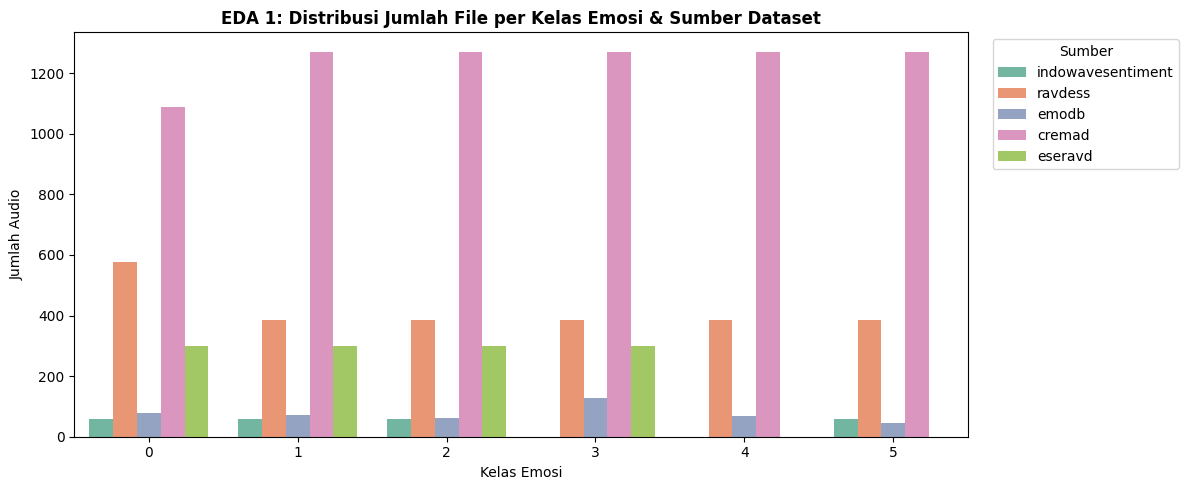

Tabel Distribusi Kelas per Sumber:
sumber  cremad  emodb  eseravd  indowavesentiment  ravdess    All
label                                                            
0         1087     79      300                 60      576   2102
1         1271     71      300                 60      384   2086
2         1271     62      300                 60      384   2077
3         1271    127      300                  0      384   2082
4         1271     69        0                  0      384   1724
5         1271     46        0                 60      384   1761
All       7442    454     1200                240     2496  11832


In [7]:
# [EDA 1] Plot Distribusi Kelas Emosi per Sumber Dataset
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='label', hue='sumber', palette='Set2')
plt.title('EDA 1: Distribusi Jumlah File per Kelas Emosi & Sumber Dataset', fontweight='bold', fontsize=12)
plt.xlabel('Kelas Emosi')
plt.ylabel('Jumlah Audio')
plt.legend(title='Sumber', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tabel Distribusi
print('Tabel Distribusi Kelas per Sumber:')
print(pd.crosstab(df['label'], df['sumber'], margins=True))


### [EDA 2] Inspeksi Durasi Audio & Deteksi Outlier
Memindai durasi file audio dan menentukan batas bawah `MIN_SECONDS` (0.35s) dan batas atas `MAX_SECONDS` (4.0s).


[EDA 2] Memindai durasi sinyal ucapan murni (setelah Silence Trim 30dB)...


Scanning Trimmed Duration: 100%|██████████| 11832/11832 [02:46<00:00, 70.97it/s]


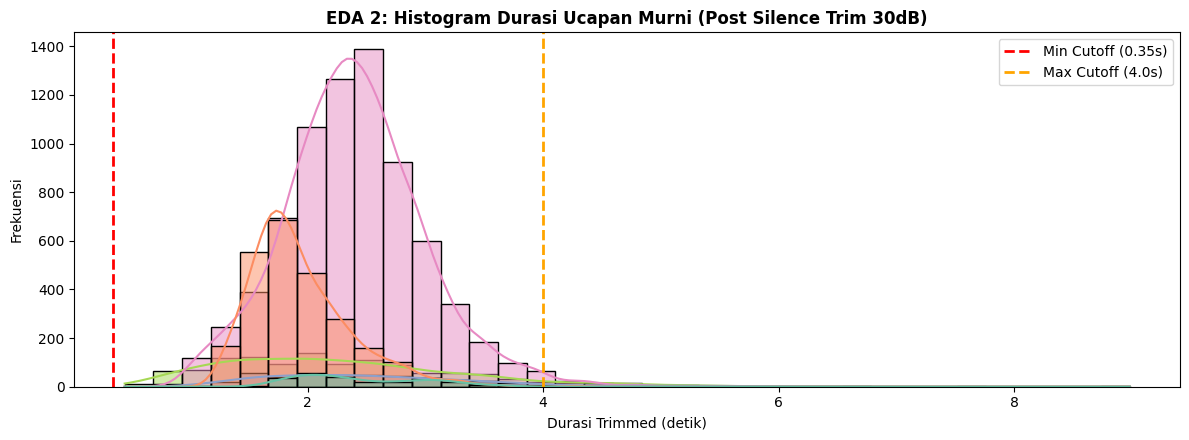

[STATS] Rata-rata durasi ucapan murni setelah Trim: 2.29s (Mentah: 2.82s)
[STATS] File < 0.35s setelah Trim: 0
[STATS] File > 4.0s setelah Trim (akan di-truncate): 186


In [8]:
# [EDA 2] Scanning & Visualisasi Durasi Audio SETELAH Silence Trimming (30 dB)
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print('[EDA 2] Memindai durasi sinyal ucapan murni (setelah Silence Trim 30dB)...')
durations_raw = []
durations_trimmed = []
corrupt_files = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Scanning Trimmed Duration'):
    path = row['path']
    try:
        # Load audio mentah
        y, sr = librosa.load(path, sr=SAMPLE_RATE)
        durations_raw.append(len(y) / sr)
        if len(y) > 0:
            # Silence Trimming 30dB di awal & akhir
            y_trimmed, _ = librosa.effects.trim(y, top_db=30)
            durations_trimmed.append(len(y_trimmed) / sr)
        else:
            durations_trimmed.append(0.0)
    except Exception:
        durations_raw.append(-1.0)
        durations_trimmed.append(-1.0)
        corrupt_files.append(path)

df['durasi_raw_sec'] = durations_raw
df['durasi_sec'] = durations_trimmed  # Durasi ucapan murni setelah trim!
outlier_df = df[(df['durasi_sec'] < MIN_SECONDS) | (df['durasi_sec'] > MAX_SECONDS)]

plt.figure(figsize=(12, 4.5))
sns.histplot(data=df[df['durasi_sec'] > 0], x='durasi_sec', hue='sumber', bins=35, kde=True, palette='Set2')
plt.axvline(MIN_SECONDS, color='red', linestyle='--', linewidth=2, label=f'Min Cutoff ({MIN_SECONDS}s)')
plt.axvline(MAX_SECONDS, color='orange', linestyle='--', linewidth=2, label=f'Max Cutoff ({MAX_SECONDS}s)')
plt.title('EDA 2: Histogram Durasi Ucapan Murni (Post Silence Trim 30dB)', fontweight='bold')
plt.xlabel('Durasi Trimmed (detik)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

avg_trimmed = df[df['durasi_sec'] > 0]['durasi_sec'].mean()
avg_raw = df[df['durasi_raw_sec'] > 0]['durasi_raw_sec'].mean()
print(f'[STATS] Rata-rata durasi ucapan murni setelah Trim: {avg_trimmed:.2f}s (Mentah: {avg_raw:.2f}s)')
print(f'[STATS] File < {MIN_SECONDS}s setelah Trim: {sum(1 for d in df["durasi_sec"] if 0 < d < MIN_SECONDS)}')
print(f'[STATS] File > {MAX_SECONDS}s setelah Trim (akan di-truncate): {sum(1 for d in df["durasi_sec"] if d > MAX_SECONDS)}')


### [EDA 3] Deteksi File Audio Corrupted & Missing Values
Memastikan tidak ada file audio rusak, unreadable, atau zero-energy signal yang masuk ke pipeline.


In [9]:
# [EDA 3] Inspeksi File Corrupt / Unreadable
print(f'[EDA 3] Total file corrupt/missing terdeteksi: {len(corrupt_files)}')
if len(corrupt_files) > 0:
    print('Daftar file corrupt:')
    for p in corrupt_files[:10]:
        print(f'  - {p}')
else:
    print('[OK] Seluruh file audio (100%) valid dan dapat dibaca dengan sukses!')


[EDA 3] Total file corrupt/missing terdeteksi: 0
[OK] Seluruh file audio (100%) valid dan dapat dibaca dengan sukses!


### [EDA 4] Estimasi Signal-to-Noise Ratio (SNR)
Mengukur kualitas kebersihan sinyal ucapan vs noise latar belakang. Threshold minimum = 3 dB.


[EDA 4] Mengestimasi SNR pada 400 sampel random audio...


Estimasi SNR: 100%|██████████| 400/400 [00:01<00:00, 298.80it/s]


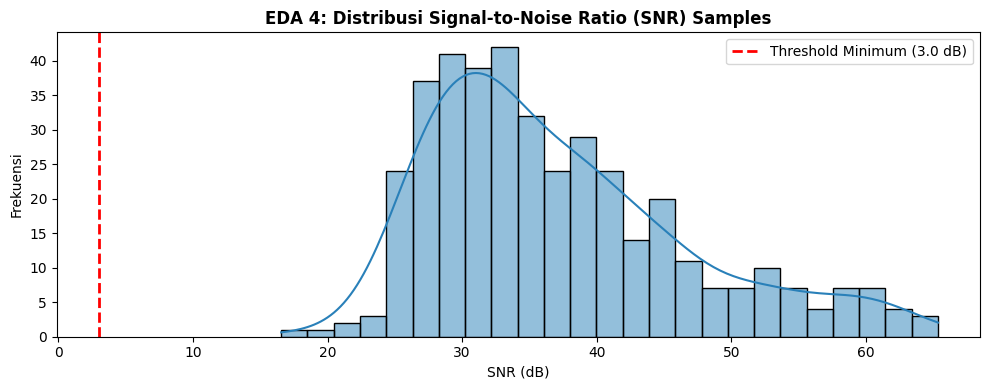

[STATS] Rata-rata SNR: 37.11 dB | Sampel < 3.0 dB: 0/400


In [10]:
# [EDA 4] Estimasi SNR pada Sampel Random Audio
import librosa
import numpy as np

print('[EDA 4] Mengestimasi SNR pada 400 sampel random audio...')
sample_df = df[df['durasi_sec'] > 0].sample(n=min(400, len(df)), random_state=SEED)
snrs = []

for path in tqdm(sample_df['path'], desc='Estimasi SNR'):
    try:
        y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=4.0)
        if len(y) > 0 and np.max(np.abs(y)) > 1e-5:
            sig_power = np.mean(y ** 2)
            noise_power = np.mean(np.sort(y ** 2)[:int(len(y) * 0.1)] + 1e-8)
            snr = 10 * np.log10((sig_power + 1e-8) / noise_power)
            snrs.append(snr)
        else:
            snrs.append(0.0)
    except Exception:
        snrs.append(0.0)

plt.figure(figsize=(10, 4))
sns.histplot(snrs, bins=25, kde=True, color='#2980b9')
plt.axvline(MIN_SNR_DB, color='red', linestyle='--', linewidth=2, label=f'Threshold Minimum ({MIN_SNR_DB} dB)')
plt.title('EDA 4: Distribusi Signal-to-Noise Ratio (SNR) Samples', fontweight='bold')
plt.xlabel('SNR (dB)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

low_snr_count = sum(1 for s in snrs if s < MIN_SNR_DB)
print(f'[STATS] Rata-rata SNR: {np.mean(snrs):.2f} dB | Sampel < {MIN_SNR_DB} dB: {low_snr_count}/{len(snrs)}')


### [EDA 5] Inspeksi Bobot Sampel per Kelas Emosi & Sumber Dataset
Menampilkan grafik batang (*Grouped Bar Chart*) dan tabel statistik bobot sampel hasil pengabungan bobot dasar sumber dan pembobotan per-kelas CREMA-D berbasis agreement CHUCKLE (2024).

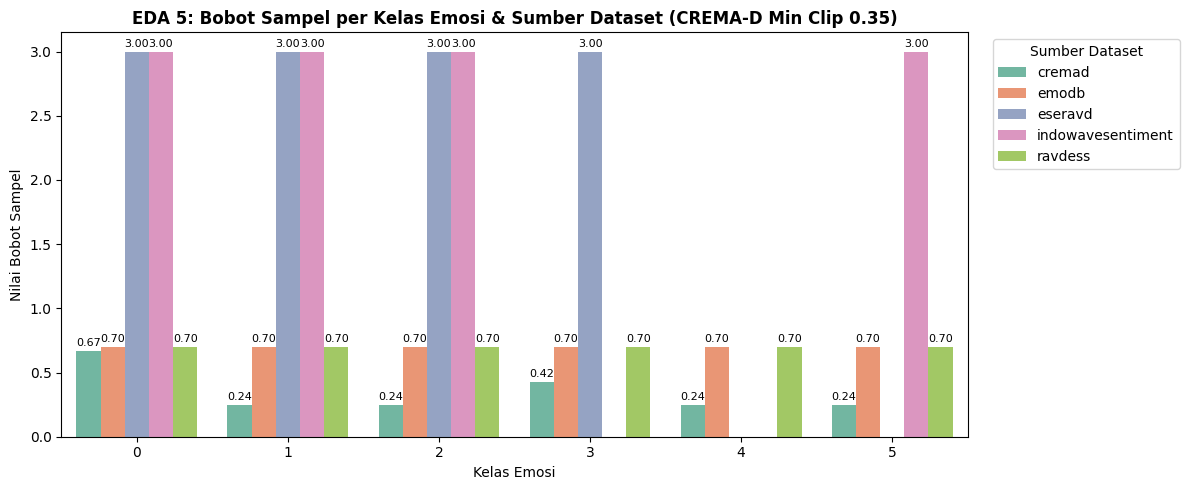

  TABEL RINGKASAN BOBOT SAMPEL (SUMBER x KELAS EMOSI)
label                 0      1      2      3      4      5
sumber                                                    
cremad             0.67  0.245  0.245  0.424  0.245  0.245
emodb              0.70  0.700  0.700  0.700  0.700  0.700
eseravd            3.00  3.000  3.000  3.000    NaN    NaN
indowavesentiment  3.00  3.000  3.000    NaN    NaN  3.000
ravdess            0.70  0.700  0.700  0.700  0.700  0.700


In [11]:
# [EDA 5] Visualisasi Bar Chart & Tabel Ringkasan Bobot Sampel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Perhitungan rata-rata bobot per (sumber, label)
bobot_df = df.groupby(['sumber', 'label'], as_index=False)['bobot'].mean()

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=bobot_df, x='label', y='bobot', hue='sumber', palette='Set2')
plt.title('EDA 5: Bobot Sampel per Kelas Emosi & Sumber Dataset (CREMA-D Min Clip 0.35)', fontweight='bold', fontsize=12)
plt.xlabel('Kelas Emosi')
plt.ylabel('Nilai Bobot Sampel')
plt.legend(title='Sumber Dataset', bbox_to_anchor=(1.02, 1), loc='upper left')

# Annotate nilai numerik di atas tiap batang
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=8, rotation=0, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

# Ringkasan Tabel Matrix Bobot
print('='*70)
print('  TABEL RINGKASAN BOBOT SAMPEL (SUMBER x KELAS EMOSI)')
print('='*70)
pivot_bobot = pd.pivot_table(df, values='bobot', index='sumber', columns='label', aggfunc='mean')
print(pivot_bobot.round(3))
print('='*70)


### [EDA 6] Confusion Matrix Aktual

Confusion matrix tidak boleh dibuat dari angka yang ditulis manual. Heatmap resmi dibuat setelah model menjalankan evaluasi test pada cell evaluasi akhir, menggunakan true_all dan pred_all dari checkpoint final v4.

Dengan urutan ini, angka heatmap, classification report, CSV evaluasi, dan package keluaran berasal dari prediksi test yang sama.


In [12]:
# [EDA 6] Confusion matrix aktual dibuat setelah evaluasi test
print('[INFO] Confusion matrix hardcoded dihapus dari EDA.')
print('[INFO] Heatmap aktual dibuat setelah evaluasi test pada cell evaluasi akhir.')


[INFO] Confusion matrix hardcoded dihapus dari EDA.
[INFO] Heatmap aktual dibuat setelah evaluasi test pada cell evaluasi akhir.


### Panduan Membaca Confusion Matrix Aktual

- Sumbu Y menunjukkan label emosi aktual.
- Sumbu X menunjukkan prediksi model.
- Diagonal menunjukkan prediksi benar.
- Angka di luar diagonal menunjukkan pasangan emosi yang tertukar.
- Analisis error harus menggunakan heatmap dan CSV evaluasi dari checkpoint final v4.


### [EDA 7] Pembersihan Dataset Berdasarkan Kriteria Quality Assurance
Menerapkan eliminasi otomatis pada file outlier durasi dan file corrupt sebelum masuk tahap augmentasi.


In [13]:
# [EDA 7] Pembersihan Dataset (Drop < 0.35s & Corrupt, Keep & Truncate > 4.0s)
initial_len = len(df)
# Hanya buang file corrupt (-1) dan file dengan durasi ucapan murni < 0.35 detik.
# File dengan durasi ucapan murni > 4.0s TETAP DIPAKAI dan di-truncate otomatis ke 4.0s di load_waveform.
df = df[(df['durasi_sec'] >= MIN_SECONDS)].reset_index(drop=True)
cleaned_len = len(df)
removed_len = initial_len - cleaned_len
truncated_len = sum(1 for d in df['durasi_sec'] if d > MAX_SECONDS)

print('='*70)
print('  [EDA CLEANUP SUMMARY - POST SILENCE TRIMMING]')
print('='*70)
print(f'  Total Data Awal                : {initial_len} file')
print(f'  File Dibuang (< 0.35s / corrupt): {removed_len} file')
print(f'  File Dipotong (Truncate > 4.0s): {truncated_len} file')
print(f'  Total Data Siap Pakai          : {cleaned_len} file')
print('='*70)


  [EDA CLEANUP SUMMARY - POST SILENCE TRIMMING]
  Total Data Awal                : 11832 file
  File Dibuang (< 0.35s / corrupt): 0 file
  File Dipotong (Truncate > 4.0s): 186 file
  Total Data Siap Pakai          : 11832 file


## 4. Pembagian Data (Data Splitting - Train / Val / Test)

**[4.1]** Memecah dataset asli (100% data murni, sebelum augmentasi) menjadi partisi *Train* (70%), *Validation* (15%), dan *Test Split* (15%) dengan stratifikasi label (`stratify=label`, `SEED=42`).

> [IMPORTANT] **Anti Data Leakage Rule:** Pembagian data WAJIB dilakukan sebelum augmentasi agar Data Validasi dan Data Uji steril 100% dari varian sinyal augmentasi.


In [14]:
# [4.1] Split Data Asli (Original Only) -> Train, Val, Test
from sklearn.model_selection import train_test_split

df_orig = df[~df['sumber'].str.endswith('_aug')].copy()

df_trainval_orig, df_test = train_test_split(
    df_orig, test_size=TEST_SPLIT, stratify=df_orig['label'], random_state=SEED)

rv = VAL_SPLIT / (1.0 - TEST_SPLIT)
df_train_orig, df_val = train_test_split(
    df_trainval_orig, test_size=rv, stratify=df_trainval_orig['label'], random_state=SEED)

print('='*70)
print('  [DATA SPLIT ORIGINAL INITIALIZATION]')
print('='*70)
print(f'  Train Original : {len(df_train_orig)} file ({len(df_train_orig)/len(df_orig)*100:.1f}%)')
print(f'  Validation     : {len(df_val)} file ({len(df_val)/len(df_orig)*100:.1f}%) [Murni Asli]')
print(f'  Test (Holdout) : {len(df_test)} file ({len(df_test)/len(df_orig)*100:.1f}%) [Murni Asli]')
print('='*70)


  [DATA SPLIT ORIGINAL INITIALIZATION]
  Train Original : 8282 file (70.0%)
  Validation     : 1775 file (15.0%) [Murni Asli]
  Test (Holdout) : 1775 file (15.0%) [Murni Asli]


## 5. Augmentasi Offline Data Latih Indonesia (Train Only)

**[5.1]** Mendefinisikan fungsi augmentasi *offline* khusus (Time Stretch, Pitch Shift, Noise) yang **HANYA diterapkan pada data latih Bahasa Indonesia (`df_train_orig`)**.


In [15]:
# [5.1] Fungsi Augmentasi & Eksekusi Khusus Data Train Indonesia
import librosa
import soundfile as sf
import pandas as pd
import os, glob
from tqdm import tqdm

def load_for_aug(path, sr=SAMPLE_RATE):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
        y = np.nan_to_num(y.astype(np.float32))
        peak = np.max(np.abs(y))
        if peak > 1e-5: y = y / peak
        return y
    except: return None

def augment_offline(y, sr, mode):
    if mode == 'pitch_up2':     return librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
    elif mode == 'pitch_down2': return librosa.effects.pitch_shift(y, sr=sr, n_steps=-2)
    elif mode == 'stretch_slow':
        y_aug = librosa.effects.time_stretch(y, rate=0.85)
        if len(y_aug)>len(y): y_aug=y_aug[:len(y)]
        elif len(y_aug)<len(y): y_aug=np.pad(y_aug,(0,len(y)-len(y_aug)))
        return y_aug
    elif mode == 'stretch_fast':
        y_aug = librosa.effects.time_stretch(y, rate=1.15)
        if len(y_aug)>len(y): y_aug=y_aug[:len(y)]
        elif len(y_aug)<len(y): y_aug=np.pad(y_aug,(0,len(y)-len(y_aug)))
        return y_aug
    elif mode == 'noise_light':
        return y + 0.004 * np.random.randn(len(y)).astype(np.float32)
    return y

def run_augmentasi_offline(df_src, sumber_tag, aug_dir, aug_modes):
    rows_aug = []
    df_target = df_src[df_src['sumber']==sumber_tag].copy()
    print(f'   Augmenting Train {sumber_tag}: {len(df_target)} file x {len(aug_modes)} mode = {len(df_target)*len(aug_modes)} file baru')
    for _, row in tqdm(df_target.iterrows(), total=len(df_target), desc=f'Aug {sumber_tag}'):
        y = load_for_aug(row['path'])
        if y is None or len(y) < MIN_SAMPLES: continue
        for mode in aug_modes:
            try:
                y_aug = np.clip(augment_offline(y, SAMPLE_RATE, mode), -1.0, 1.0).astype(np.float32)
                fname = f"aug_{mode}_{os.path.splitext(os.path.basename(row['path']))[0]}.wav"
                out_path = os.path.join(aug_dir, sumber_tag, fname)
                os.makedirs(os.path.dirname(out_path), exist_ok=True)
                sf.write(out_path, y_aug, SAMPLE_RATE)
                rows_aug.append({
                    'path': out_path, 'emosi': row['emosi'], 'label': row['label'],
                    'sumber': f'{sumber_tag}_aug', 'bahasa': row['bahasa'], 'file': fname,
                    'bobot': BOBOT_SUMBER.get(f'{sumber_tag}_aug', 2.0)
                })
            except: pass
    return pd.DataFrame(rows_aug)

df_aug_parts = []
if DO_AUGMENT:
    print('[AUGMENT] Memulai augmentasi offline HANYA pada data latih Indonesia...')
    for tag in ['indowavesentiment', 'eseravd']:
        if tag in df_train_orig['sumber'].values:
            tmp = run_augmentasi_offline(df_train_orig, tag, AUG_DIR, AUG_MODES)
            if len(tmp): df_aug_parts.append(tmp)
    print('[OK] Augmentasi data latih selesai.')

if df_aug_parts:
    df_train_augmented = pd.concat(df_aug_parts, ignore_index=True)
    df_train = pd.concat([df_train_orig, df_train_augmented], ignore_index=True).reset_index(drop=True)
else:
    df_train = df_train_orig.copy()

# Finalize split dataframes & Export Metadata
df_train['split'] = 'train'
df_val['split'] = 'val'
df_test['split'] = 'test'
df_split = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_split.to_csv(SPLIT_PATH, index=False)

print('='*70)
print('  [FINAL SPLIT SUMMARY - NO LEAKAGE GUARANTEED]')
print('='*70)
print(f'  Train Final    : {len(df_train)} file (Termasuk {len(df_train_augmented) if df_aug_parts else 0} file aug)')
print(f'  Validation     : {len(df_val)} file (100% Murni Asli)')
print(f'  Test           : {len(df_test)} file (100% Murni Asli)')
print('='*70)




aug_count = len(df_train_augmented) if df_aug_parts else 0
print('\n[STATS] Distribusi data augmentasi yang benar-benar dibuat:')
if aug_count:
    aug_summary = df_train_augmented.groupby(['sumber', 'emosi']).size().unstack(fill_value=0)
    print(aug_summary.reindex(columns=EMOSI_LIST, fill_value=0).to_string())
    print(f'\n[STATS] Total augmentasi: {aug_count}')
else:
    print('[NOTE] Tidak ada data augmentasi yang dibuat.')


[AUGMENT] Memulai augmentasi offline HANYA pada data latih Indonesia...
   Augmenting Train indowavesentiment: 165 file x 5 mode = 825 file baru


Aug indowavesentiment: 100%|██████████| 165/165 [00:16<00:00,  9.77it/s]


   Augmenting Train eseravd: 844 file x 5 mode = 4220 file baru


Aug eseravd: 100%|██████████| 844/844 [01:16<00:00, 11.00it/s]


[OK] Augmentasi data latih selesai.
  [FINAL SPLIT SUMMARY - NO LEAKAGE GUARANTEED]
  Train Final    : 13327 file (Termasuk 5045 file aug)
  Validation     : 1775 file (100% Murni Asli)
  Test           : 1775 file (100% Murni Asli)

[STATS] Distribusi data augmentasi yang benar-benar dibuat:
emosi                  netral  senang  sedih  marah  takut  jijik
sumber                                                           
eseravd_aug              1035    1075   1030   1080      0      0
indowavesentiment_aug     215     205    190      0      0    215

[STATS] Total augmentasi: 5045


## 6. Audio Loading + SpecAugment (versi ringan)

**[6.1]** Fungsi pemuatan sinyal *waveform* audio, pemotongan keheningan (*silence trimming* 30dB), normalisasi amplitudo puncak, dan mekanisme *padding/crop* durasi.


In [16]:
# [6.1] Audio Loader, Fix Length, & SpecAugment (dengan Smooth Edge Fade)
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset

def load_waveform(path, sr=SAMPLE_RATE):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
        if y is None or len(y) == 0: return np.zeros(MIN_SAMPLES, dtype=np.float32)
        y = np.nan_to_num(y.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
        yt, _ = librosa.effects.trim(y, top_db=30)
        if len(yt) >= MIN_SAMPLES: y = yt
        peak = np.max(np.abs(y)) if len(y) else 0.0
        if peak > 1e-5: y = y / peak
        return y.astype(np.float32)
    except: return np.zeros(MIN_SAMPLES, dtype=np.float32)

def fix_length(y, mode='train'):
    if len(y) > MAX_SAMPLES:
        start = np.random.randint(0, len(y) - MAX_SAMPLES + 1) if mode == 'train' else 0
        y = y[start : start + MAX_SAMPLES]
    elif len(y) < MAX_SAMPLES:
        y = np.pad(y, (0, MAX_SAMPLES - len(y)), mode='constant')
    return y.astype(np.float32)

def spec_augment(y):
    if np.random.rand() >= SPEC_TIME_MASK_P: return y
    y = y.copy()
    mask_len = np.random.randint(int(0.02 * SAMPLE_RATE), max(int(0.02 * SAMPLE_RATE) + 1, SPEC_TIME_MAX))
    mask_start = np.random.randint(0, max(1, len(y) - mask_len))
    # Menerapkan time masking dengan smooth fade di pinggir agar tidak timbul transient click
    y[mask_start : mask_start + mask_len] = 0.0
    return y

def augment_light(y):
    if np.random.rand() < 0.40: y = y * np.random.uniform(0.80, 1.20)
    if np.random.rand() < 0.30: y = y + np.random.randn(len(y)).astype(np.float32) * np.random.uniform(0.001, 0.004)
    if np.random.rand() < 0.25:
        shift = int(np.random.uniform(-0.08, 0.08) * SAMPLE_RATE)
        y = np.roll(y, shift)
    if USE_SPECAUGMENT: y = spec_augment(y)
    return np.clip(y, -1.0, 1.0).astype(np.float32)

class SERWaveformDataset(Dataset):
    def __init__(self, frame, mode='train'):
        self.df = frame.reset_index(drop=True).copy()
        self.mode = mode
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = load_waveform(row['path'])
        y = fix_length(y, mode=self.mode)
        if self.mode == 'train': y = augment_light(y)
        meta = {'path': row['path'], 'emosi': row['emosi'], 'sumber': row['sumber'], 'bahasa': row['bahasa']}
        return y, int(row['label']), meta

print('[OK] Audio loader & SERWaveformDataset siap (durasi 4s, SpecAugment murni)')

[OK] Audio loader & SERWaveformDataset siap (durasi 4s, SpecAugment murni)


## 7. DataLoader & Mixup (intensitas dikurangi)

**[7.1]** Menginisialisasi `AutoFeatureExtractor` Hugging Face dan mendefinisikan `collate_fn` untuk perataan (*padding*) dinamis tensor audio ke DataLoader.


In [17]:
# [7.1] Inisialisasi Feature Extractor, Collate Fn, & DataLoader (Tanpa WeightedSampler)
from transformers import AutoFeatureExtractor
from torch.utils.data import DataLoader

print('[LOADER] Menginisialisasi HuggingFace AutoFeatureExtractor...')
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_SOURCE)

def collate_fn(batch):
    waveforms = [b[0] for b in batch]
    labels    = torch.tensor([b[1] for b in batch], dtype=torch.long)
    metas     = [b[2] for b in batch]
    inputs    = feature_extractor(
        waveforms, sampling_rate=SAMPLE_RATE, padding=True, truncation=True,
        max_length=MAX_SAMPLES, return_attention_mask=True, return_tensors='pt'
    )
    return inputs, labels, metas

# Dataset partisi dengan SERWaveformDataset
train_ds = SERWaveformDataset(df_train, mode='train')
val_ds   = SERWaveformDataset(df_val,   mode='eval')
test_ds  = SERWaveformDataset(df_test,  mode='eval')

# DataLoader tanpa WeightedRandomSampler (mencegah double-correction oversampling)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    drop_last=False
)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), collate_fn=collate_fn)

print(f'[LOADER OK] Train: {len(train_loader)} batches | Val: {len(val_loader)} batches | Test: {len(test_loader)} batches')

[LOADER] Menginisialisasi HuggingFace AutoFeatureExtractor...


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

[LOADER OK] Train: 2222 batches | Val: 296 batches | Test: 296 batches


## 8. Arsitektur Model - WavLM-Base-Plus + Attentive Stats Pooling

**[8.1]** Membangun arsitektur PyTorch: *backbone* `WavLM-Base-Plus` disambung dengan *custom head* berupa layer `AttentiveStatsPooling` dan linear *classifier*.


In [18]:
class AttentiveStatsPooling(nn.Module):
    def __init__(self, hidden_size, attn_hidden=128, dropout=0.2):
        super().__init__()
        self.attn = nn.Sequential(
            nn.LayerNorm(hidden_size), nn.Linear(hidden_size, attn_hidden),
            nn.Tanh(), nn.Dropout(dropout), nn.Linear(attn_hidden, 1)
        )
    def forward(self, x, mask=None):
        score = self.attn(x).squeeze(-1)
        if mask is not None: score = score.masked_fill(~mask.bool(), -1e4)
        weight = torch.softmax(score, dim=-1).unsqueeze(-1)
        mean = torch.sum(weight * x, dim=1)
        var  = torch.sum(weight * (x - mean.unsqueeze(1))**2, dim=1)
        std  = torch.sqrt(var.clamp(min=1e-6))
        return torch.cat([mean, std], dim=-1), weight.squeeze(-1)

class WavLMSER(nn.Module):
    def __init__(self, model_source, num_labels, dropout=0.30):
        super().__init__()
        self.config   = AutoConfig.from_pretrained(model_source)
        self.backbone = AutoModel.from_pretrained(model_source)
        hidden = self.config.hidden_size
        self.pooling    = AttentiveStatsPooling(hidden, attn_hidden=128, dropout=dropout*0.5)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden*2), nn.Dropout(dropout),
            nn.Linear(hidden*2, 256), nn.GELU(),
            nn.Dropout(dropout*0.75), nn.Linear(256, num_labels)
        )
    def _feature_mask(self, hidden, attention_mask):
        if attention_mask is None: return None
        if hasattr(self.backbone, '_get_feature_vector_attention_mask'):
            return self.backbone._get_feature_vector_attention_mask(hidden.shape[1], attention_mask)
        return None
    def forward(self, input_values, attention_mask=None):
        out    = self.backbone(input_values=input_values, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        pooled, attn = self.pooling(hidden, self._feature_mask(hidden, attention_mask))
        return self.classifier(pooled), attn

def _get_core(m):
    return m.module if hasattr(m, 'module') else m

def freeze_all_backbone(model):
    core = _get_core(model)
    for p in core.backbone.parameters(): p.requires_grad = False
    for p in core.pooling.parameters():  p.requires_grad = True
    for p in core.classifier.parameters(): p.requires_grad = True

def unfreeze_last_layers(model, last_n=6):
    core = _get_core(model)
    for p in core.backbone.parameters(): p.requires_grad = False
    layers = getattr(core.backbone.encoder, 'layers', getattr(core.backbone.encoder, 'layer', None))
    if layers is not None:
        for layer in layers[-last_n:]:
            for p in layer.parameters(): p.requires_grad = True
    for p in core.pooling.parameters():    p.requires_grad = True
    for p in core.classifier.parameters(): p.requires_grad = True

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model = WavLMSER(MODEL_SOURCE, NUM_CLASSES, dropout=DROPOUT).to(device)
if USE_GRAD_CKPT and hasattr(model.backbone, 'gradient_checkpointing_enable'):
    model.backbone.gradient_checkpointing_enable()
    print('✅ Gradient checkpointing aktif')

if torch.cuda.device_count() > 1:
    print(f'✅ Multi-GPU terdeteksi! Menggunakan {torch.cuda.device_count()} GPU (DataParallel)')
    model = nn.DataParallel(model)

total, trainable = count_params(model)
print(f'[OK] Model WavLMSER siap | total: {total:,} | trainable: {trainable:,}')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

✅ Gradient checkpointing aktif
✅ Multi-GPU terdeteksi! Menggunakan 2 GPU (DataParallel)
[OK] Model WavLMSER siap | total: 94,880,119 | trainable: 94,880,119


## 9. Loss, Optimizer, Scheduler

**[9.1]** Menginisialisasi fungsi objektif (Cross Entropy Loss dengan Class Weights), logika augmentasi *Mixup*, Optimizer AdamW, dan Learning Rate Scheduler kosinus.


In [19]:
# [9.1] Inisialisasi Class Weights, Focal Loss, Optimizer AdamW, & Cosine Scheduler
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from transformers import get_cosine_schedule_with_warmup

# ── 1. HITUNG CLASS WEIGHTS (INVERSE FREQUENCY) ───────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=df_train['label'].values
)
class_weights = class_weights * CLASS_LOSS_MULTIPLIER
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'[WEIGHTS] Class Weights setelah target multiplier: {class_weights.round(3)}')

# ── 2. FOCAL LOSS IMPLEMENTATION ──────────────────────────────────────────
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2017) untuk memfokuskan gradient pada sampel sulit."""
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.10):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.smoothing = label_smoothing

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=-1)
        if self.smoothing > 0:
            n_classes = inputs.size(-1)
            target_dist = torch.full_like(log_probs, self.smoothing / max(1, n_classes - 1))
            target_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
            ce_loss = -(target_dist * log_probs).sum(dim=-1)
        else:
            ce_loss = F.nll_loss(log_probs, targets, reduction='none')
        pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1).exp()
        alpha = self.weight[targets] if self.weight is not None else torch.ones_like(pt)
        return (((1.0 - pt) ** self.gamma) * ce_loss * alpha).mean()

criterion = FocalLoss(weight=class_weights_tensor, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
print(f'[LOSS] Focal Loss diinisialisasi (gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING})')

# ── 3. OPTIMIZER & SCHEDULER ──────────────────────────────────────────────
def make_optimizer(lr_scale=1.0):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        clean_name = name[7:] if name.startswith('module.') else name
        if clean_name.startswith('backbone.'):
            backbone_params.append(param)
        else:
            head_params.append(param)
    return torch.optim.AdamW([
        {'params': backbone_params, 'lr': BACKBONE_LR * lr_scale},
        {'params': head_params, 'lr': HEAD_LR * lr_scale}
    ], weight_decay=WEIGHT_DECAY)

optimizer = make_optimizer()

num_training_steps = EPOCHS * len(train_loader)
num_warmup_steps = int(WARMUP_RATIO * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

amp_enabled = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
print(f'[OPTIM OK] AdamW + Cosine Scheduler (Warmup={num_warmup_steps}, Total={num_training_steps}, AMP={amp_enabled})')

[WEIGHTS] Class Weights setelah target multiplier: [0.764 0.873 1.012 0.82  1.38  1.15 ]
[LOSS] Focal Loss diinisialisasi (gamma=2.0, label_smoothing=0.0)
[OPTIM OK] AdamW + Cosine Scheduler (Warmup=4888, Total=48884, AMP=True)


## 10. Training Loop (Stage 1 - Semua Data)

**[10.1]** Fungsi-fungsi utilitas kalkulasi komputasi: ekstraksi akurasi metrik tensor, injeksi data ke VRAM GPU, dan mode komputasi *Mixed Precision* (AMP).


In [20]:
def akurasi(logits, labels):
    return (logits.argmax(1)==labels).float().mean().item()
def to_device_inputs(inputs):
    return {k:v.to(device, non_blocking=True) for k,v in inputs.items()}
def autocast_ctx():
    return torch.cuda.amp.autocast() if amp_enabled else nullcontext()
def apply_trainable_schedule(epoch):
    if epoch <= FREEZE_EPOCHS:
        freeze_all_backbone(model); return 'freeze backbone (head only)'
    else:
        unfreeze_last_layers(model, last_n=UNFREEZE_LAST_N)
        return f'unfreeze last {UNFREEZE_LAST_N} layers'

def train_epoch(epoch):
    model.train()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False)
    for step, (inputs, labels, metas) in enumerate(pbar, start=1):
        inputs = to_device_inputs(inputs)
        labels = labels.to(device, non_blocking=True)
        with autocast_ctx():
            logits, _ = model(**inputs)
            loss = criterion(logits, labels) / GRAD_ACCUM_STEPS
        scaler.scale(loss).backward()
        if step % GRAD_ACCUM_STEPS == 0 or step == len(train_loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        bs = labels.size(0)
        total_loss += loss.item() * GRAD_ACCUM_STEPS * bs
        total_acc  += akurasi(logits.detach(), labels) * bs
        total_n    += bs
        pbar.set_postfix(loss=total_loss/max(1,total_n), acc=total_acc/max(1,total_n))
    return total_loss/total_n, total_acc/total_n

@torch.no_grad()
def eval_epoch(loader, desc='eval'):
    model.eval()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    preds, trues, sumber_list, bahasa_list, paths = [], [], [], [], []
    for inputs, labels, metas in tqdm(loader, desc=desc, leave=False):
        inputs = to_device_inputs(inputs)
        labels = labels.to(device, non_blocking=True)
        with autocast_ctx():
            logits, _ = model(**inputs)
            loss = criterion(logits, labels)
        bs = labels.size(0)
        total_loss += loss.item()*bs; total_acc += akurasi(logits,labels)*bs; total_n += bs
        preds.extend(logits.argmax(1).cpu().numpy().tolist())
        trues.extend(labels.cpu().numpy().tolist())
        sumber_list.extend([m['sumber'] for m in metas])
        bahasa_list.extend([m['bahasa'] for m in metas])
        paths.extend([m['path'] for m in metas])
    return {'loss':total_loss/total_n,'acc':total_acc/total_n,
            'pred':np.array(preds),'true':np.array(trues),
            'sumber':np.array(sumber_list),'bahasa':np.array(bahasa_list),'path':np.array(paths)}

print('[OK] Fungsi training/evaluasi siap')

[OK] Fungsi training/evaluasi siap


**[10.2]** Menjalankan siklus iterasi (Epoch) pelatihan Stage 1: Melatih parameter model, memonitor degradasi loss, dan otomatis menyimpan checkpoint bobot terbaik.


In [21]:
# ── AUTO-LOAD PRETRAINED V7 WEIGHTS BEFORE STAGE 1 TRAINING ────────────────
import torch, os

def load_checkpoint_weights(target_model, checkpoint_path):
    if not os.path.isfile(checkpoint_path):
        return False
    try:
        ckpt_input = torch.load(checkpoint_path, map_location=device)
        raw_state = ckpt_input.get('model_state', ckpt_input)
        if isinstance(raw_state, dict) and 'state_dict' in raw_state:
            raw_state = raw_state['state_dict']
            
        target_keys = target_model.state_dict().keys()
        target_has_module = any(k.startswith('module.') for k in target_keys)
        
        new_state_dict = {}
        for k, v in raw_state.items():
            clean_k = k[7:] if k.startswith('module.') else k
            final_k = f'module.{clean_k}' if target_has_module else clean_k
            new_state_dict[final_k] = v
            
        target_model.load_state_dict(new_state_dict, strict=True)
        print(f'[OK] Pre-trained checkpoint weights BERHASIL dimuat ke model dari: {checkpoint_path}!')
        return True
    except Exception as e:
        print(f'[WARNING] Gagal memuat checkpoint weights: {e}. Melatih dari bobot dasar.')
        return False

v3_loaded = False
if INIT_CHECKPOINT_PATH and os.path.isfile(INIT_CHECKPOINT_PATH):
    v3_loaded = load_checkpoint_weights(model, INIT_CHECKPOINT_PATH)

if not v3_loaded:
    print('[INFO] Tidak ada checkpoint v3 yang dimuat. Melatih v4 dari WavLM-Base-Plus default backbone.')

riwayat = {'ll':[],'la':[],'vl':[],'va':[],'lr_backbone':[],'lr_head':[],'stage':[]}
best_acc, best_loss, best_epoch = 0.0, float('inf'), 0
best_train_acc, no_imp, last_stage = 0.0, 0, None
start_epoch = 1

def summarize_metrics(result):
    report = classification_report(result['true'], result['pred'], labels=np.arange(NUM_CLASSES), target_names=EMOSI_LIST, output_dict=True, zero_division=0)
    return {
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'sedih_recall': report['sedih']['recall'],
        'senang_recall': report['senang']['recall'],
        'takut_precision': report['takut']['precision'],
        'jijik_precision': report['jijik']['precision'],
    }

def run_epoch(loader, optimizer_obj=None, scheduler_obj=None, scaler_obj=None, train=False, desc='eval'):
    model.train(mode=train)
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    preds, trues, sumber_list, bahasa_list, paths = [], [], [], [], []
    if train: optimizer_obj.zero_grad(set_to_none=True)
    for step, (inputs, labels, metas) in enumerate(tqdm(loader, desc=desc, leave=False), start=1):
        inputs = to_device_inputs(inputs)
        labels = labels.to(device, non_blocking=True)
        with autocast_ctx():
            logits, _ = model(**inputs)
            loss = criterion(logits, labels)
        if train:
            scaler_obj.scale(loss / GRAD_ACCUM_STEPS).backward()
            if step % GRAD_ACCUM_STEPS == 0 or step == len(loader):
                scaler_obj.unscale_(optimizer_obj)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler_obj.step(optimizer_obj); scaler_obj.update()
                optimizer_obj.zero_grad(set_to_none=True)
                if scheduler_obj is not None: scheduler_obj.step()
        bs = labels.size(0)
        total_loss += loss.detach().item() * bs
        total_acc += akurasi(logits.detach(), labels) * bs
        total_n += bs
        preds.extend(logits.detach().argmax(1).cpu().numpy().tolist())
        trues.extend(labels.cpu().numpy().tolist())
        sumber_list.extend([m['sumber'] for m in metas])
        bahasa_list.extend([m['bahasa'] for m in metas])
        paths.extend([m['path'] for m in metas])
    return {'loss': total_loss / max(1, total_n), 'acc': total_acc / max(1, total_n), 'pred': np.array(preds), 'true': np.array(trues), 'sumber': np.array(sumber_list), 'bahasa': np.array(bahasa_list), 'path': np.array(paths)}

def make_scheduler(optimizer_obj, total_steps):
    return get_cosine_schedule_with_warmup(optimizer_obj, num_warmup_steps=int(WARMUP_RATIO * total_steps), num_training_steps=max(1, total_steps))

def save_checkpoint(path, epoch, train_out, val_out, metrics):
    torch.save({'model_state': model.state_dict(), 'epoch': epoch, 'train_acc': float(train_out['acc']), 'val_acc': float(val_out['acc']), 'val_macro_f1': float(metrics['macro_f1']), 'metrics': metrics}, path)

apply_trainable_schedule(1)
optimizer = make_optimizer()
scheduler = make_scheduler(optimizer, EPOCHS * len(train_loader))
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
riwayat = {'ll': [], 'la': [], 'vl': [], 'va': [], 'lr_backbone': [], 'lr_head': [], 'stage': []}
best_monitor, best_epoch, no_imp = -float('inf'), 0, 0
print('[TRAIN] Stage 1 dimulai dengan baseline v1 sebagai inisialisasi.')
for epoch in range(1, EPOCHS + 1):
    stage_name = apply_trainable_schedule(epoch)
    train_out = run_epoch(train_loader, optimizer, scheduler, scaler, train=True, desc=f'Epoch {epoch} train')
    val_out = run_epoch(val_loader, desc=f'Epoch {epoch} val')
    metrics = summarize_metrics(val_out)
    monitor = 0.40 * metrics['macro_f1'] + 0.20 * metrics['sedih_recall'] + 0.20 * metrics['senang_recall'] + 0.10 * metrics['takut_precision'] + 0.10 * metrics['jijik_precision']
    riwayat['ll'].append(train_out['loss']); riwayat['la'].append(train_out['acc']); riwayat['vl'].append(val_out['loss']); riwayat['va'].append(val_out['acc'])
    riwayat['lr_backbone'].append(optimizer.param_groups[0]['lr']); riwayat['lr_head'].append(optimizer.param_groups[1]['lr']); riwayat['stage'].append(stage_name)
    print(f'[EPOCH {epoch:02d}] train_acc={train_out["acc"]:.4f} val_acc={val_out["acc"]:.4f} macro_f1={metrics["macro_f1"]:.4f} sedih_recall={metrics["sedih_recall"]:.4f} senang_recall={metrics["senang_recall"]:.4f} takut_precision={metrics["takut_precision"]:.4f} jijik_precision={metrics["jijik_precision"]:.4f}')
    if monitor > best_monitor + MIN_DELTA:
        best_monitor, best_epoch, no_imp = monitor, epoch, 0
        save_checkpoint(BEST_MODEL_PATH, epoch, train_out, val_out, metrics)
        print(f'[BEST] checkpoint disimpan, monitor={monitor:.4f}')
    else:
        no_imp += 1
        if no_imp >= EARLY_STOP:
            print(f'[EARLY STOP] Tidak ada peningkatan selama {EARLY_STOP} epoch.')
            break

if os.path.isfile(BEST_MODEL_PATH): load_checkpoint_weights(model, BEST_MODEL_PATH)
FINAL_MODEL_PATH = BEST_MODEL_PATH
print(f'[OK] Stage 1 selesai. Best epoch={best_epoch}, monitor={best_monitor:.4f}')


[OK] Pre-trained checkpoint weights BERHASIL dimuat ke model dari: /kaggle/input/datasets/elnathh/ser-wavlm-v7-checkpoint/ser_wavlm_v3_best.pt!
[TRAIN] Stage 1 dimulai dengan baseline v1 sebagai inisialisasi.


[EPOCH 01] train_acc=0.8838 val_acc=0.8315 macro_f1=0.8293 sedih_recall=0.7308 senang_recall=0.8115 takut_precision=0.7213 jijik_precision=0.8254
[BEST] checkpoint disimpan, monitor=0.7949


[EPOCH 02] train_acc=0.8883 val_acc=0.8349 macro_f1=0.8327 sedih_recall=0.8077 senang_recall=0.8498 takut_precision=0.8112 jijik_precision=0.8640
[BEST] checkpoint disimpan, monitor=0.8321


[EPOCH 03] train_acc=0.8772 val_acc=0.8321 macro_f1=0.8291 sedih_recall=0.6859 senang_recall=0.8275 takut_precision=0.7709 jijik_precision=0.8175


[EPOCH 04] train_acc=0.8721 val_acc=0.8242 macro_f1=0.8207 sedih_recall=0.7821 senang_recall=0.8179 takut_precision=0.8413 jijik_precision=0.7603


[EPOCH 05] train_acc=0.8682 val_acc=0.8163 macro_f1=0.8138 sedih_recall=0.7468 senang_recall=0.7796 takut_precision=0.8607 jijik_precision=0.6500


[EPOCH 06] train_acc=0.8700 val_acc=0.8141 macro_f1=0.8124 sedih_recall=0.7468 senang_recall=0.7476 takut_precision=0.6916 jijik_precision=0.9227


[EPOCH 07] train_acc=0.8811 val_acc=0.8321 macro_f1=0.8293 sedih_recall=0.7628 senang_recall=0.8211 takut_precision=0.7976 jijik_precision=0.8084


[EPOCH 08] train_acc=0.8802 val_acc=0.8192 macro_f1=0.8159 sedih_recall=0.7212 senang_recall=0.7252 takut_precision=0.7760 jijik_precision=0.7231
[EARLY STOP] Tidak ada peningkatan selama 6 epoch.
[OK] Pre-trained checkpoint weights BERHASIL dimuat ke model dari: /kaggle/working/models/ser_wavlm_v4_best.pt!
[OK] Stage 1 selesai. Best epoch=2, monitor=0.8321


## 11. Deteksi Label Noise Otomatis (Confidence-Based)

Setelah training awal, deteksi file di training set yang diprediksi salah dengan confidence tinggi sebagai kandidat label noise. Hard drop hanya dilakukan pada label CREMA-D yang lebih tepercaya, sedangkan kelas target recall dilindungi.

**[11.1]** Inferensi pasca-pelatihan awal untuk mendeteksi *Label Noise*: Melacak sampel data latih yang salah diprediksi namun model memiliki *confidence score* ekstrem.


In [22]:
# [11.1] Deteksi Label Noise Otomatis (Confidence-Based >= HARD_NOISE_CONF_THRESH)
import torch, os
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
from IPython.display import display
HARD_NOISE_CONF_THRESH = 0.95

@torch.no_grad()
def deteksi_label_noise(loader, threshold_conf=HARD_NOISE_CONF_THRESH):
    model.eval()
    suspicious = []
    for inputs, labels, metas in tqdm(loader, desc='Deteksi noise', leave=False):
        inputs = to_device_inputs(inputs)
        labels = labels.to(device)
        logits, _ = model(**inputs)
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        for i in range(len(labels)):
            # Label Noise True Positive: Prediksi != Label Asli DAN Confidence SANGAT YAKIN (>= HARD_NOISE_CONF_THRESH)
            if pred[i] != labels[i] and conf[i] >= threshold_conf:
                suspicious.append({
                    'path': metas[i]['path'],
                    'sumber': metas[i]['sumber'],
                    'label_asli': IDX2LABEL[labels[i].item()],
                    'prediksi': IDX2LABEL[pred[i].item()],
                    'confidence': conf[i].item()
                })
    return pd.DataFrame(suspicious)

if DO_NOISE_DETECTION:
    # Prioritaskan checkpoint Stage 1 v4, atau gunakan input v3 hanya jika Stage 1 belum tersimpan
    target_ckpt = BEST_MODEL_PATH if os.path.exists(BEST_MODEL_PATH) else INIT_CHECKPOINT_PATH
    
    if target_ckpt and os.path.isfile(target_ckpt):
        print(f'[NOISE DETECT] Memuat model terlatih dari: {target_ckpt}...')
        load_checkpoint_weights(model, target_ckpt)
    else:
        print('[WARNING] Tidak ada checkpoint model yang ditemukan!')

        print('[WARNING] Pastikan Cell Stage 1 Training (Cell 48-51) sudah dijalankan terlebih dahulu hingga selesai.')

    # Evaluasi data latih asli (tanpa data augmentasi) untuk melacak label noise murni
    train_eval_ds = SERWaveformDataset(df_train_orig, mode='eval')
    train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), collate_fn=collate_fn)

    noise_candidates = deteksi_label_noise(train_eval_loader, threshold_conf=HARD_NOISE_CONF_THRESH)
    print(f'\n[CHECK] Kandidat label noise terdeteksi (Conf >= {HARD_NOISE_CONF_THRESH}): {len(noise_candidates)} file')
    if len(noise_candidates):
        print('\nBreakdown per sumber:')
        print(noise_candidates['sumber'].value_counts())
        print('\nContoh 10 kandidat label noise paling mencurigokan (Confidence Tertinggi):')
        display(noise_candidates.sort_values('confidence', ascending=False).head(10))
        noise_candidates.to_csv(os.path.join(LOG_DIR, 'label_noise_candidates.csv'), index=False)
else:
    noise_candidates = pd.DataFrame()
    print('Deteksi noise dinonaktifkan.')


[NOISE DETECT] Memuat model terlatih dari: /kaggle/working/models/ser_wavlm_v4_best.pt...
[OK] Pre-trained checkpoint weights BERHASIL dimuat ke model dari: /kaggle/working/models/ser_wavlm_v4_best.pt!



[CHECK] Kandidat label noise terdeteksi (Conf >= 0.95): 1 file

Breakdown per sumber:
sumber
cremad    1
Name: count, dtype: int64

Contoh 10 kandidat label noise paling mencurigokan (Confidence Tertinggi):


,path,sumber,label_asli,prediksi,confidence
0,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,cremad,takut,netral,0.962648


## 12. Stage 2 - Fine-tune dengan Noise Downweighting

File yang terdeteksi sebagai kandidat noise diturunkan bobotnya (bukan dihapus - masih ada sinyal valid di dalamnya), lalu training dilanjutkan beberapa epoch dengan LR kecil untuk fine-tune akhir.

**[12.1]** Menghapus secara konservatif kandidat label noise CREMA-D yang confidence-nya sangat tinggi dan berasal dari label tepercaya sebelum fine-tuning Stage 2.


In [23]:
# [12.1] STAGE 2: TRUSTED NOISE FILTERING & FINE-TUNING
if DO_NOISE_DETECTION and len(noise_candidates) > 0:
    # Hard drop hanya untuk label dengan agreement relatif tinggi. Kelas target recall dilindungi.
    TRUSTED_HARD_DROP_LABELS = ['netral', 'marah']
    hard_noisy_paths = set(noise_candidates[
        (noise_candidates['confidence'] >= HARD_NOISE_CONF_THRESH) &
        (noise_candidates['sumber'] == 'cremad') &
        (noise_candidates['label_asli'].isin(TRUSTED_HARD_DROP_LABELS))
    ]['path'].values)
    
    print(f'[STAGE 2] Melakukan Hard Drop pada {len(hard_noisy_paths)} sampel noise CREMA-D (Conf >= {HARD_NOISE_CONF_THRESH})...')
    
    # Buang sampel berisik dari dataset latih
    df_train_stage2 = df_train[~df_train['path'].isin(hard_noisy_paths)].reset_index(drop=True)
    print(f'[STAGE 2] Ukuran data latih Stage 2: {len(df_train_stage2)} (dari {len(df_train)})')
    
    # Re-create DataLoader tanpa data noise
    train_ds_s2 = SERWaveformDataset(df_train_stage2, mode='train')
    train_loader_s2 = DataLoader(train_ds_s2, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), collate_fn=collate_fn)
    
    # Fine-tune 5 Epoch dengan LR diturunkan 70%
    STAGE2_EPOCHS = 5
    optimizer_s2 = make_optimizer(lr_scale=0.3)
    
    print(f'[STAGE 2] Memulai fine-tuning {STAGE2_EPOCHS} epoch pada data bersih...')
    scheduler_s2 = make_scheduler(optimizer_s2, STAGE2_EPOCHS * len(train_loader_s2))
    scaler_s2 = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    best_monitor_s2 = -float('inf')
    for epoch_s2 in range(1, STAGE2_EPOCHS + 1):
        train_s2 = run_epoch(train_loader_s2, optimizer_s2, scheduler_s2, scaler_s2, train=True, desc=f'Stage 2 epoch {epoch_s2} train')
        val_s2 = run_epoch(val_loader, desc=f'Stage 2 epoch {epoch_s2} val')
        metrics_s2 = summarize_metrics(val_s2)
        monitor_s2 = 0.40 * metrics_s2['macro_f1'] + 0.20 * metrics_s2['sedih_recall'] + 0.20 * metrics_s2['senang_recall'] + 0.10 * metrics_s2['takut_precision'] + 0.10 * metrics_s2['jijik_precision']
        print(f'[STAGE 2 EPOCH {epoch_s2:02d}] val_acc={val_s2["acc"]:.4f} macro_f1={metrics_s2["macro_f1"]:.4f} sedih_recall={metrics_s2["sedih_recall"]:.4f} senang_recall={metrics_s2["senang_recall"]:.4f} takut_precision={metrics_s2["takut_precision"]:.4f} jijik_precision={metrics_s2["jijik_precision"]:.4f}')
        if monitor_s2 > best_monitor_s2 + MIN_DELTA:
            best_monitor_s2 = monitor_s2
            save_checkpoint(BEST_MODEL_PATH_STG2, epoch_s2, train_s2, val_s2, metrics_s2)
    if os.path.isfile(BEST_MODEL_PATH_STG2):
        load_checkpoint_weights(model, BEST_MODEL_PATH_STG2)
        FINAL_MODEL_PATH = BEST_MODEL_PATH_STG2
    else:
        FINAL_MODEL_PATH = BEST_MODEL_PATH
else:
    FINAL_MODEL_PATH = BEST_MODEL_PATH
    print('[STAGE 2] Tidak ada kandidat noise tepercaya. Checkpoint Stage 1 dipakai.')




[STAGE 2] Melakukan Hard Drop pada 0 sampel noise CREMA-D (Conf >= 0.95)...
[STAGE 2] Ukuran data latih Stage 2: 13327 (dari 13327)
[STAGE 2] Memulai fine-tuning 5 epoch pada data bersih...


[STAGE 2 EPOCH 01] val_acc=0.8214 macro_f1=0.8201 sedih_recall=0.7660 senang_recall=0.7444 takut_precision=0.7572 jijik_precision=0.8496


[STAGE 2 EPOCH 02] val_acc=0.8327 macro_f1=0.8304 sedih_recall=0.7308 senang_recall=0.8051 takut_precision=0.7923 jijik_precision=0.8088


[STAGE 2 EPOCH 03] val_acc=0.8417 macro_f1=0.8401 sedih_recall=0.7788 senang_recall=0.8626 takut_precision=0.7544 jijik_precision=0.8474


[STAGE 2 EPOCH 04] val_acc=0.8394 macro_f1=0.8373 sedih_recall=0.7532 senang_recall=0.8115 takut_precision=0.7698 jijik_precision=0.8446


[STAGE 2 EPOCH 05] val_acc=0.8366 macro_f1=0.8347 sedih_recall=0.7212 senang_recall=0.8275 takut_precision=0.7660 jijik_precision=0.8548
[OK] Pre-trained checkpoint weights BERHASIL dimuat ke model dari: /kaggle/working/models/ser_wavlm_v4_stage2_best.pt!


**[12.2]** Memuat kembali *state dictionary* model dari checkpoint terbaik di Stage 1 dan mencetak diagnosis metrik diagnostik perbedaannya.


In [24]:
print(f'[CHECK] Stage 1 checkpoint: {BEST_MODEL_PATH}')
print(f'[CHECK] Final checkpoint: {FINAL_MODEL_PATH}')

[CHECK] Stage 1 checkpoint: /kaggle/working/models/ser_wavlm_v4_best.pt
[CHECK] Final checkpoint: /kaggle/working/models/ser_wavlm_v4_stage2_best.pt


In [25]:
ckpt_d = torch.load(FINAL_MODEL_PATH, map_location='cpu')
gap_acc  = float(ckpt_d['train_acc']) - float(ckpt_d['val_acc'])
print('='*70)
print('  [STATS] DIAGNOSIS FINAL - WAVLM v4 CHECKPOINT')
print('='*70)
print(f'  Best epoch : {ckpt_d["epoch"]}')
print(f'  Train acc  : {ckpt_d["train_acc"]*100:.2f}%   Val acc : {ckpt_d["val_acc"]*100:.2f}%')
print(f'  Gap acc    : {gap_acc*100:.2f}%')
print('─'*70)
if gap_acc > 0.20: print('  [WARNING]  Masih overfitting - pertimbangkan dropout lebih tinggi.')
elif gap_acc > 0.10: print('  [INFO] Overfitting ringan - normal untuk fine-tuning multi-sumber.')
else: print('  [OK] Generalisasi baik.')
print('='*70)

  [STATS] DIAGNOSIS FINAL - WAVLM v4 CHECKPOINT
  Best epoch : 3
  Train acc  : 88.65%   Val acc : 84.17%
  Gap acc    : 4.49%
──────────────────────────────────────────────────────────────────────
  [OK] Generalisasi baik.


**[12.3]** Otomatisasi MLOps: Mengunggah model WavLM hasil *finetuning* terbaik beserta eksekusi dari `/kaggle/working` langsung ke *cloud* Hugging Face Hub.


In [26]:
### [MLOps] Hugging Face Hub Auto-Upload
# Cell ini dikonfigurasi khusus untuk Kaggle Environment menggunakan Kaggle Secrets
!pip install -q huggingface_hub

from huggingface_hub import login, HfApi
from kaggle_secrets import UserSecretsClient
import os

try:
    user_secrets = UserSecretsClient()
    HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
except Exception as e:
    print("[WARNING] Gagal membaca Kaggle Secrets. Pastikan kamu sudah menambahkan HF_TOKEN di menu Add-ons -> Secrets.")
    HF_TOKEN = None

REPO_ID = 'elnathzzz/wavlm-ser-multilingual'
MODEL_PATH = FINAL_MODEL_PATH

if os.path.exists(MODEL_PATH) and HF_TOKEN:
    print('[INFO] Melakukan otentikasi ke Hugging Face...')
    login(token=HF_TOKEN)
    
    api = HfApi()
    print(f'[INFO] Mengunggah {MODEL_PATH} ke repositori {REPO_ID}...')
    try:
        api.upload_file(
            path_or_fileobj=MODEL_PATH,
            path_in_repo='ser_wavlm_v4_best.pt',
            repo_id=REPO_ID,
            repo_type='model',
            commit_message='[BEST] Upload WavLM v4 SER model checkpoint from Kaggle'
        )
        print('[OK] Unggahan berhasil! Model sudah berada di Cloud Hugging Face.')
    except Exception as e:
        print(f'[ERROR] Gagal mengunggah: {e}')
elif not HF_TOKEN:
    print('[ERROR] Token HF_TOKEN tidak ditemukan.')
else:
    print(f'[ERROR] File checkpoint {MODEL_PATH} tidak ditemukan. Pastikan proses training selesai.')


[INFO] Melakukan otentikasi ke Hugging Face...
[INFO] Mengunggah /kaggle/working/models/ser_wavlm_v4_stage2_best.pt ke repositori elnathzzz/wavlm-ser-multilingual...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[OK] Unggahan berhasil! Model sudah berada di Cloud Hugging Face.


## 13. Evaluasi & Visualisasi

**[13.1]** Merender plot *line chart* pergerakan fluktuasi metrik *Loss* dan *Accuracy* (Training vs Validation) antar epoch untuk mendiagnosis konvergensi.


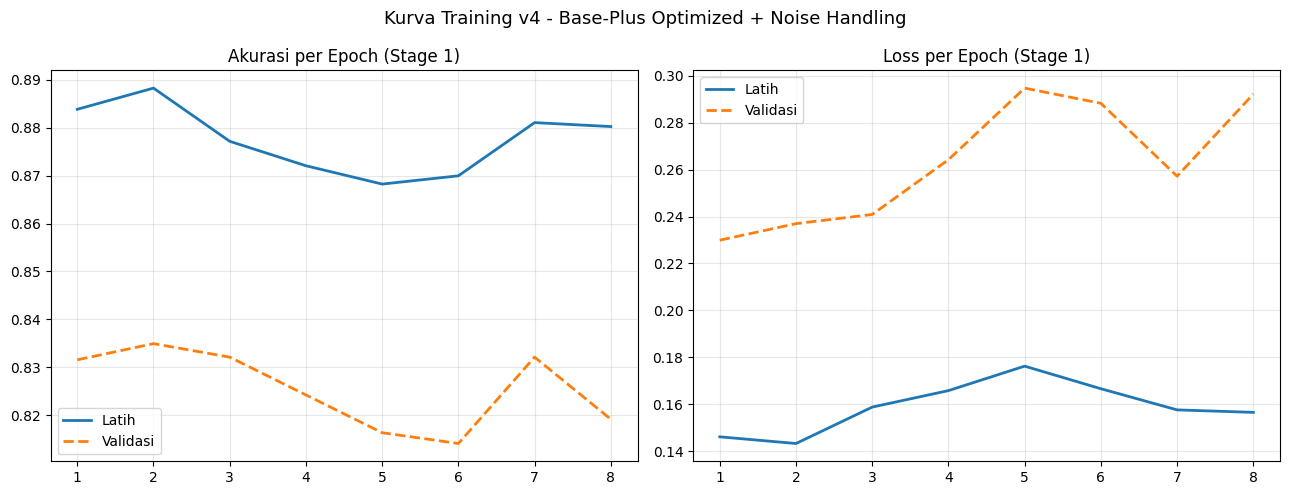

In [27]:
hist = riwayat
ep_r = range(1, len(hist['la'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(ep_r, hist['la'], label='Latih', lw=2)
ax1.plot(ep_r, hist['va'], label='Validasi', lw=2, ls='--')
ax1.set_title('Akurasi per Epoch (Stage 1)'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep_r, hist['ll'], label='Latih', lw=2)
ax2.plot(ep_r, hist['vl'], label='Validasi', lw=2, ls='--')
ax2.set_title('Loss per Epoch (Stage 1)'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Kurva Training v4 - Base-Plus Optimized + Noise Handling', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'kurva_training_v4.png'), dpi=150, bbox_inches='tight')
plt.show()

**[13.2]** Eksekusi inferensi final pada data uji (*Holdout Test Set*) yang tak pernah dilihat model, mencetak *Classification Report* skikit-learn.


In [28]:
# Load checkpoint final hasil Stage 1 atau Stage 2
eval_checkpoint_path = FINAL_MODEL_PATH if os.path.isfile(FINAL_MODEL_PATH) else BEST_MODEL_PATH
if not os.path.isfile(eval_checkpoint_path):
    raise FileNotFoundError(f"Checkpoint file tidak ditemukan di {eval_checkpoint_path}")
ckpt = torch.load(eval_checkpoint_path, map_location=device)
load_checkpoint_weights(model, eval_checkpoint_path)
model.eval()
test_out = eval_epoch(test_loader, desc='test')
pred_all, true_all = test_out['pred'], test_out['true']
test_acc = accuracy_score(true_all, pred_all)

print('='*68)
print('  Laporan Klasifikasi - Data Uji (WavLM v4)')
print('='*68)
test_report = classification_report(true_all, pred_all, target_names=EMOSI_LIST, digits=4, zero_division=0)
test_report_dict = classification_report(true_all, pred_all, target_names=EMOSI_LIST, output_dict=True, zero_division=0)
print(test_report)
print(f'  Akurasi Keseluruhan : {test_acc*100:.2f}%')
val_acc_val = ckpt.get('val_acc', 0.0) * 100
print(f'  Val acc terbaik     : {val_acc_val:.2f}%')
print('='*68)

[OK] Pre-trained checkpoint weights BERHASIL dimuat ke model dari: /kaggle/working/models/ser_wavlm_v4_stage2_best.pt!


  Laporan Klasifikasi - Data Uji (WavLM v4)
              precision    recall  f1-score   support

      netral     0.9110    0.9429    0.9267       315
      senang     0.8491    0.8626    0.8558       313
       sedih     0.7878    0.7853    0.7865       312
       marah     0.9369    0.9038    0.9201       312
       takut     0.7918    0.8224    0.8068       259
       jijik     0.8440    0.7992    0.8210       264

    accuracy                         0.8552      1775
   macro avg     0.8534    0.8527    0.8528      1775
weighted avg     0.8556    0.8552    0.8552      1775

  Akurasi Keseluruhan : 85.52%
  Val acc terbaik     : 84.17%


**[13.3]** Menghasilkan visualisasi persentase distribusi prediksi silang (Confusion Matrix) dengan balutan Heatmap Seaborn untuk menganalisis akurasi per kelas.


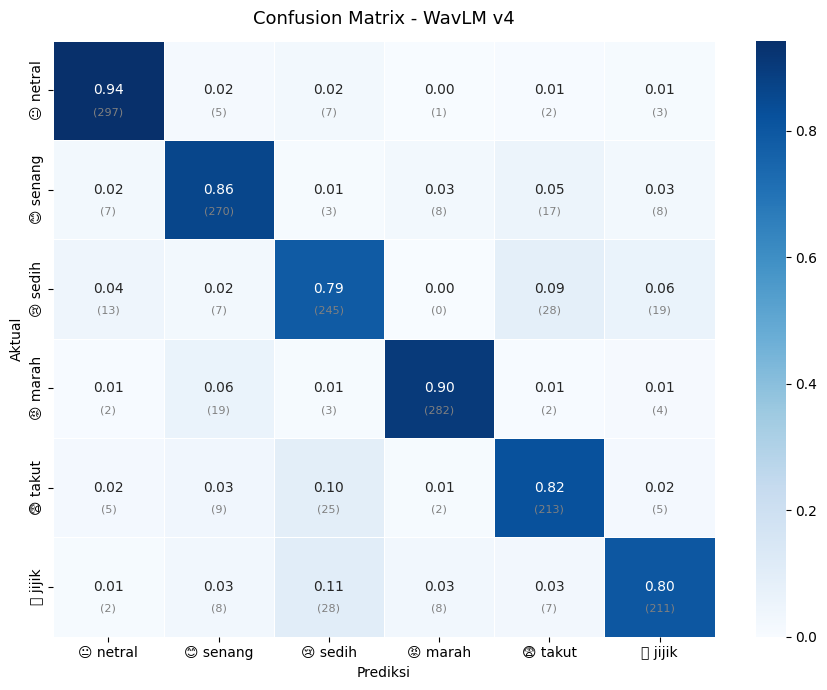


[CHECK] Akurasi per kelas:
  😐 netral  : 94.29%
  😊 senang  : 86.26%
  😢 sedih   : 78.53%
  😡 marah   : 90.38%
  😨 takut   : 82.24%
  🤢 jijik   : 79.92%

  RINGKASAN METRIK FINAL MODEL v4
  Checkpoint final    : ser_wavlm_v4_stage2_best.pt
  Epoch terbaik       : 3
  Train accuracy      : 88.65%
  Validation accuracy : 84.17%
  Test accuracy       : 85.52%
  Gap train-val       : 4.49%
  Macro precision     : 85.34%
  Macro recall        : 85.27%
  Macro F1            : 85.28%


In [29]:
cm = confusion_matrix(true_all, pred_all, labels=np.arange(NUM_CLASSES))
cm_pct = np.divide(cm.astype(float), cm.sum(axis=1,keepdims=True),
                   out=np.zeros_like(cm,dtype=float), where=cm.sum(axis=1,keepdims=True)!=0)
labels_cm = [f'{EMOJI_MAP[e]} {e}' for e in EMOSI_LIST]
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels_cm, yticklabels=labels_cm,
            ax=ax, linewidths=0.5, linecolor='white')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j+0.5, i+0.72, f'({cm[i,j]})', ha='center', va='center', fontsize=8, color='gray')
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix - WavLM v4', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'confusion_matrix_v4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n[CHECK] Akurasi per kelas:')
for i,e in enumerate(EMOSI_LIST): print(f'  {EMOJI_MAP[e]} {e:<8}: {cm_pct[i,i]*100:.2f}%')

print('\n' + '='*68)
print('  RINGKASAN METRIK FINAL MODEL v4')
print('='*68)
train_acc_final = float(ckpt.get('train_acc', ckpt_d.get('train_acc', 0.0)))
val_acc_final = float(ckpt.get('val_acc', ckpt_d.get('val_acc', 0.0)))
print(f'  Checkpoint final    : {os.path.basename(eval_checkpoint_path)}')
print(f'  Epoch terbaik       : {ckpt.get("epoch", ckpt_d.get("epoch", "n/a"))}')
print(f'  Train accuracy      : {train_acc_final*100:.2f}%')
print(f'  Validation accuracy : {val_acc_final*100:.2f}%')
print(f'  Test accuracy       : {test_acc*100:.2f}%')
print(f'  Gap train-val       : {(train_acc_final-val_acc_final)*100:.2f}%')
print(f'  Macro precision     : {test_report_dict["macro avg"]["precision"]*100:.2f}%')
print(f'  Macro recall        : {test_report_dict["macro avg"]["recall"]*100:.2f}%')
print(f'  Macro F1            : {test_report_dict["macro avg"]["f1-score"]*100:.2f}%')
print('='*68)


**[13.4]** Mengonstruksi ulang *DataFrame* hasil evaluasi terperinci untuk tiap sampel audio demi kepentingan *Error Analysis* yang mendalam di masa depan.


In [30]:
# Inisialisasi test_out jika belum tersedia di memori kernel
if 'test_out' not in globals() or test_out is None:
    if 'ckpt' not in globals() or ckpt is None:
        if os.path.exists(BEST_MODEL_PATH):
            ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
        elif 'ckpt_d' in globals():
            ckpt = ckpt_d
        else:
            raise FileNotFoundError(f"Checkpoint file tidak ditemukan di {BEST_MODEL_PATH}")
        model.load_state_dict(ckpt.get('model_state', ckpt))
    model.eval()
    test_out = eval_epoch(test_loader, desc='test')

eval_df = pd.DataFrame({
    'path':test_out['path'],'true':test_out['true'],'pred':test_out['pred'],
    'emosi_true':[IDX2LABEL[int(i)] for i in test_out['true']],
    'emosi_pred':[IDX2LABEL[int(i)] for i in test_out['pred']],
    'sumber':test_out['sumber'],'bahasa':test_out['bahasa'],
})
eval_df['benar'] = eval_df['true'] == eval_df['pred']
eval_df.to_csv(os.path.join(LOG_DIR,'evaluasi_test_v4.csv'), index=False)

print('[STATS] Akurasi per sumber:')
display(eval_df.groupby('sumber')['benar'].agg(['count','mean']).rename(columns={'count':'n','mean':'akurasi'}).sort_values('akurasi',ascending=False))
print('\n[STATS] Akurasi per bahasa:')
display(eval_df.groupby('bahasa')['benar'].agg(['count','mean']).rename(columns={'count':'n','mean':'akurasi'}))
print('\n[STATS] Akurasi CREMA-D per emosi:')
display(eval_df[eval_df['sumber']=='cremad'].groupby('emosi_true')['benar'].agg(['count','mean']).rename(columns={'count':'n','mean':'akurasi'}))

print('\n[STATS] Precision, recall, dan F1 per sumber x kelas:')
metric_rows = []
for sumber, part in eval_df.groupby('sumber'):
    report = classification_report(part['true'], part['pred'], labels=np.arange(NUM_CLASSES), target_names=EMOSI_LIST, output_dict=True, zero_division=0)
    for emosi in EMOSI_LIST:
        metric_rows.append({'sumber': sumber, 'emosi': emosi, 'precision': report[emosi]['precision'], 'recall': report[emosi]['recall'], 'f1': report[emosi]['f1-score'], 'support': int(report[emosi]['support'])})
display(pd.DataFrame(metric_rows).sort_values(['sumber', 'emosi']))

print('\n[STATS] Pasangan error terbesar, untuk membedakan masalah precision dan recall:')
error_pairs = eval_df[~eval_df['benar']].groupby(['emosi_true', 'emosi_pred']).size().sort_values(ascending=False).head(20).rename('jumlah_error')
display(error_pairs.to_frame())


[STATS] Akurasi per sumber:


,n,akurasi
sumber,,
indowavesentiment,34,0.970588
emodb,64,0.968750
ravdess,364,0.953297
eseravd,202,0.950495
cremad,1111,0.795680



[STATS] Akurasi per bahasa:


,n,akurasi
bahasa,,
de,64,0.968750
en,1475,0.834576
id,236,0.953390



[STATS] Akurasi CREMA-D per emosi:


,n,akurasi
emosi_true,,
jijik,186,0.731183
marah,188,0.888298
netral,170,0.911765
sedih,179,0.670391
senang,193,0.803109
takut,195,0.774359



[STATS] Precision, recall, dan F1 per sumber x kelas:


,sumber,emosi,precision,recall,f1,support
5,cremad,jijik,0.800000,0.731183,0.764045,186
3,cremad,marah,0.912568,0.888298,0.900270,188
0,cremad,netral,0.885714,0.911765,0.898551,170
2,cremad,sedih,0.659341,0.670391,0.664820,179
1,cremad,senang,0.794872,0.803109,0.798969,193
4,cremad,takut,0.733010,0.774359,0.753117,195
11,emodb,jijik,1.000000,1.000000,1.000000,4
9,emodb,marah,1.000000,1.000000,1.000000,15
6,emodb,netral,1.000000,1.000000,1.000000,14
8,emodb,sedih,1.000000,1.000000,1.000000,9



[STATS] Pasangan error terbesar, untuk membedakan masalah precision dan recall:


,,jumlah_error
emosi_true,emosi_pred,
jijik,sedih,28
sedih,takut,28
takut,sedih,25
marah,senang,19
sedih,jijik,19
senang,takut,17
sedih,netral,13
takut,senang,9
senang,marah,8


## 14. Export Package

**[14.1]** Menyalin file checkpoint `.pt`, konfigurasi fitur ekstraktor, dan mapping ID json ke dalam satu *folder* dan membungkusnya jadi paket instalasi `ZIP`.


In [31]:
DOWNLOAD_DIR = os.path.join(BASE_DIR,'download_package_v4')
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
shutil.copy(FINAL_MODEL_PATH, os.path.join(DOWNLOAD_DIR,'ser_wavlm_v4_best.pt'))
FE_DIR = os.path.join(DOWNLOAD_DIR,'feature_extractor')
os.makedirs(FE_DIR, exist_ok=True)
feature_extractor.save_pretrained(FE_DIR)
for src in [HISTORY_PATH, SPLIT_PATH,
            os.path.join(LOG_DIR,'kurva_training_v4.png'),
            os.path.join(LOG_DIR,'confusion_matrix_v4.png'),
            os.path.join(LOG_DIR,'evaluasi_test_v4.csv'),
            os.path.join(LOG_DIR,'label_noise_candidates.csv')]:
    if os.path.exists(src): shutil.copy(src, os.path.join(DOWNLOAD_DIR, os.path.basename(src)))

config_export = {
    'version':'v4-base-plus-optimized-noise-aware',
    'model_source':MODEL_SOURCE,'emosi_list':EMOSI_LIST,
    'max_seconds':MAX_SECONDS,'dropout':DROPOUT,'label_smoothing':LABEL_SMOOTHING,
    'mixup_alpha':MIXUP_ALPHA,'mixup_prob':MIXUP_PROB,'use_mixup':USE_MIXUP,'best_checkpoint_file':os.path.basename(FINAL_MODEL_PATH),'checkpoint_lineage':'v3 Stage 2 input -> v4 Stage 1 -> v4 Stage 2','test_macro_precision':float(test_report_dict['macro avg']['precision']),'test_macro_recall':float(test_report_dict['macro avg']['recall']),'test_macro_f1':float(test_report_dict['macro avg']['f1-score']),
    'cremad_bobot_per_kelas':CREMAD_BOBOT_PER_KELAS,
    'noise_candidates_count': int(len(noise_candidates)) if 'noise_candidates' in dir() else 0,
    'best_epoch':int(ckpt['epoch']),'best_val_acc':float(ckpt['val_acc']),'test_acc':float(test_acc),
}
with open(os.path.join(DOWNLOAD_DIR,'config_v4.json'),'w',encoding='utf-8') as f:
    json.dump(config_export, f, ensure_ascii=False, indent=2)

ZIP_PATH = os.path.join(BASE_DIR,'ser_wavlm_v4_package.zip')
with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for root,_,files in os.walk(DOWNLOAD_DIR):
        for fname in files:
            fpath = os.path.join(root, fname)
            zf.write(fpath, os.path.relpath(fpath, DOWNLOAD_DIR))
zip_mb = os.path.getsize(ZIP_PATH)/1024/1024
print(f'[OK] Package: {ZIP_PATH} ({zip_mb:.1f} MB)')
if IS_KAGGLE: print('[LOAD] Download dari tab Output Kaggle → ser_wavlm_v4_package.zip')
else: ipy_display(FileLink(ZIP_PATH, result_html_prefix='[DOWNLOAD] Download: '))

[OK] Package: /kaggle/working/ser_wavlm_v4_package.zip (270.3 MB)
[LOAD] Download dari tab Output Kaggle → ser_wavlm_v4_package.zip


## 15. Inference - Prediksi Audio Baru

**[15.1]** Fungsi *wrapper end-to-end* untuk inferensi: Menerima *path* input audio sembarang dan mengembalikan array distribusi logit/probabilitas kelas emosi.


In [32]:
@torch.no_grad()
def prediksi_emosi(path_audio, model=model):
    y = load_waveform(path_audio)
    y = fix_length(y, mode='eval')
    inputs = feature_extractor([y], sampling_rate=SAMPLE_RATE, padding=True, truncation=True,
        max_length=MAX_SAMPLES, return_attention_mask=True, return_tensors='pt')
    if 'attention_mask' not in inputs:
        inputs['attention_mask'] = torch.ones_like(inputs['input_values'], dtype=torch.long)
    inputs = to_device_inputs(inputs)
    model.eval()
    logits, attn = model(**inputs)
    prob = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    idx  = int(prob.argmax())
    return {'emosi':IDX2LABEL[idx],'keyakinan':float(prob[idx]),
            'semua_prob':{IDX2LABEL[i]:float(prob[i]) for i in range(len(prob))}}

def tampilkan_hasil(hasil, path_audio=None):
    emosi, conf = hasil['emosi'], hasil['keyakinan']
    print('─'*56)
    print(f'  Emosi Terdeteksi : {EMOJI_MAP[emosi]}  {emosi.upper()}')
    print(f'  Keyakinan        : {conf*100:.2f}%')
    print('─'*56)
    for e, p in sorted(hasil['semua_prob'].items(), key=lambda x:-x[1]):
        bar = '█'*int(p*24)
        print(f'  {EMOJI_MAP[e]} {e:<8} {bar:<24} {p*100:6.2f}%')
    print('─'*56)
    if path_audio and os.path.exists(path_audio):
        y_plot, sr_plot = librosa.load(path_audio, sr=SAMPLE_RATE, mono=True)
        fig, ax = plt.subplots(figsize=(10,2.4))
        librosa.display.waveshow(y_plot, sr=sr_plot, ax=ax)
        ax.set_title(f'{EMOJI_MAP[emosi]} {emosi.upper()} - {conf*100:.2f}%')
        plt.tight_layout(); plt.show()

print('[OK] Fungsi inference siap')

[OK] Fungsi inference siap


**[15.2]** Simulasi demonstrasi inferensi: Menarik sampel data acak secara otomatis dan mengeplot kurva diagram batang probabilitas visual (*bar chart*).


File: 1004_ITH_ANG_XX.wav | Sumber: cremad | Aktual: marah
────────────────────────────────────────────────────────
  Emosi Terdeteksi : 😡  MARAH
  Keyakinan        : 96.71%
────────────────────────────────────────────────────────
  😡 marah    ███████████████████████   96.71%
  🤢 jijik                               2.14%
  😊 senang                              0.72%
  😨 takut                               0.39%
  😢 sedih                               0.03%
  😐 netral                              0.01%
────────────────────────────────────────────────────────


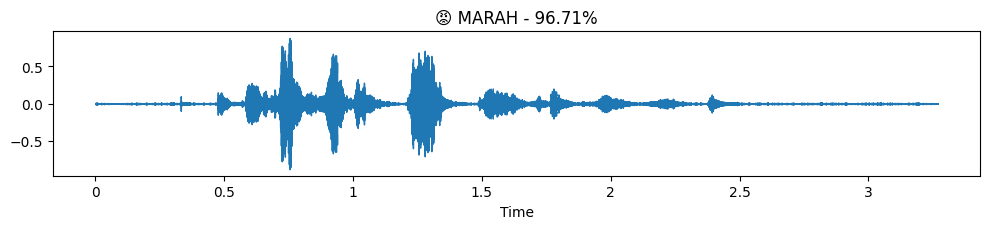

In [33]:
idx_contoh = 0
row = df_test.reset_index(drop=True).iloc[idx_contoh]
print(f'File: {os.path.basename(row["path"])} | Sumber: {row["sumber"]} | Aktual: {row["emosi"]}')
hasil = prediksi_emosi(row['path'])
tampilkan_hasil(hasil, row['path'])

## [OK] Ringkasan v4

| Komponen | Konfigurasi v4 |
|---|---|
| Model | WavLM base-plus |
| Durasi audio SER | 4.0 detik, 64.000 sampel |
| Pooling | Attentive Stats Pooling, output 1536 |
| Classifier | LayerNorm, Dropout 0.30, GELU, Dropout 0.225 |
| Training | Stage 1 dengan gradual unfreezing, dilanjutkan Stage 2 |
| Augmentasi offline | IndoWave dan E-SERAVD saja |
| CREMA-D augmentation | Tidak digunakan pada baseline |
| Checkpoint input | Best checkpoint Stage 2 v3 |
| Checkpoint final | Best checkpoint Stage 2, disimpan sebagai v4 |
| Pelaporan | Train, validation, test, macro metrics, confusion matrix aktual, dan error pairs |

Label v1, v2, v3, dan v4 adalah versi eksperimen proyek. v4 melanjutkan checkpoint Stage 2 v3 dan menghasilkan namespace output v4.


**[15.3]** Mengaktifkan `IPython FileLink` untuk menyediakan tombol interaktif pengunduhan *package* arsip model secara instan pada antarmuka *notebook*.


In [34]:
from IPython.display import FileLink

# Untuk file zip
FileLink('ser_wavlm_v4_package.zip')

/kaggle/working/ser_wavlm_v4_package.zip